# Renewables - Time  Series Analysis

## (I) Selection of a wind turbine model for a wind park project near the town of Cottbus

Inputs: Time series  of wind speeds at the site under consideration at ten meters above the ground in units of m/s. 
Consider turbine models from two different manufacturers with power curves shown in the table below. 

|Wind Speed [m/s]| Vestas [MW] |Enercon [MW]|
|----------|---------|-------------|
| <4 | 0 | 0 |
| 4-6 | 0.2 | 0.4 |
| 6-8 | 0.5 | 0.8 |
| 8-10 | 1.3 | 1.5 |
| 10-12 | 2.5 | 2.1 |
| 12-14 | 3 | 2.4 |
| 14-16 | 3 | 2.9 |
| 16- | 3 | 3 |

The wind turbines have a hub height of 90 meters and a nominal rating of 3.5 MW.<br>
The cut-out speed beyond which the wind turbine is shut down is 22 m/s for the Vestas model and 25
m/s for the Enercon model.

In [8]:
dict_table1 = {
    "Wind Speed [m/s]" : ["<4","4-6","6-8","8-10","10-12","12-14","14-16","16-"],
    "Vestas [MW]" : [0,0.2,0.5,1.3,2.5,3,3,3],
    "Enercon [MW]" : [0,0.4,0.8,1.5,2.1,2.4,2.9,3]
    
}

pd.DataFrame(dict_table1)

,Wind Speed [m/s],Vestas [MW],Enercon [MW]
0,<4,0.0,0.0
1,4-6,0.2,0.4
2,6-8,0.5,0.8
3,8-10,1.3,1.5
4,10-12,2.5,2.1
5,12-14,3.0,2.4
6,14-16,3.0,2.9
7,16-,3.0,3.0


#### Import packages

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

#### Read CSV file into pandas

In [3]:
url  = "https://tubcloud.tu-berlin.de/s/X8WGZxA6554iSz9/download/wind-speeds.csv"
ws = pd.read_csv(url, index_col = 0,parse_dates =True)
ws.head()

,wind_speed_m_s
time,
2019-01-01 00:00:00,11.484892
2019-01-01 01:00:00,11.835971
2019-01-01 02:00:00,12.323022
2019-01-01 03:00:00,13.186331
2019-01-01 04:00:00,14.068345


#### Confirm dataframe index is pd.DatetimeIndex

In [5]:
assert type(ws.index) == pd.DatetimeIndex
print("Type of index:", type(ws.index))

Type of index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


#### Convert the wind speeds to a hub height of 90 meters using Log law

In [6]:
# Hub Height, z
z = 90

# Roughness length for open flat grassland as terrain, zo
zo = 0.03

# Reference height, zr
zr =  10

# Creating a function for the Log Law
conversion_factor = np.log(z/zo)/np.log(zr/zo)
def log(U_zr):
    U_z = U_zr*conversion_factor
    return U_z

In [7]:
# Apply the fuction log to the dataframe
ws['wind_speed_m_s'] = ws['wind_speed_m_s'].apply(log)

# Print conversion factor
print(f"The converion factor is {conversion_factor:.2f} \n")

# Print wind speeds of the first ten hours
ws.head(10)

The converion factor is 1.38 



,wind_speed_m_s
time,
2019-01-01 00:00:00,15.828887
2019-01-01 01:00:00,16.312757
2019-01-01 02:00:00,16.984027
2019-01-01 03:00:00,18.173870
2019-01-01 04:00:00,19.389494
2019-01-01 05:00:00,19.311163
2019-01-01 06:00:00,18.862988
2019-01-01 07:00:00,19.221924
2019-01-01 08:00:00,19.665141


### Python function converting wind speed into power production using powr curve

In [8]:
def turbine_power(data):
    speed = data['wind_speed_m_s']
    if speed <4:
        power = [0,0]
    elif 4 <= speed < 6:
        power = [0.2,0.4]
    elif 6 <= speed < 8:
        power = [0.5,0.8]
    elif 8<= speed < 10:
        power = [1.3,1.5]
    elif 10 <= speed < 12:
        power = [2.5,2.1]
    elif 12 <= speed < 14:
        power = [3,2.4]
    elif 14 <= speed < 16:
        power = [3,2.9]
    elif 16 <= speed < 22:
        power = [3,3]
    elif 16 <= speed < 22:
        power = [3,3]
    elif 22 <= speed < 25:
        power = [0,3]
    else:
        power = [0,0]
    return power

#### Applying the fuction turbine_power to the dataframe

In [9]:
ws[['Vestas [MW]','Enercon [MW]']] = ws.apply(turbine_power,axis = 1, result_type='expand')
ws.sort_index().tail(20)

,wind_speed_m_s,Vestas [MW],Enercon [MW]
time,,,
2019-12-31 04:00:00,16.740109,3.0,3.0
2019-12-31 05:00:00,17.295369,3.0,3.0
2019-12-31 06:00:00,17.921029,3.0,3.0
2019-12-31 07:00:00,17.924003,3.0,3.0
2019-12-31 08:00:00,16.604268,3.0,3.0
2019-12-31 09:00:00,15.113989,3.0,2.9
2019-12-31 10:00:00,14.391159,3.0,2.9
2019-12-31 11:00:00,14.201776,3.0,2.9
2019-12-31 12:00:00,13.643541,3.0,2.4


#### Turbine with the most energy output in the year

In [10]:
# Total energy output by each turbine
vestas_energy = ws['Vestas [MW]'].sum()
enercon_energy = ws['Enercon [MW]'].sum()

if vestas_energy > enercon_energy:
    print(f"Vestas Turbine yields the most energy output in the year by a relative margin of: {(vestas_energy - enercon_energy)/vestas_energy*100:.2f}%")
else:
    print(f"Enercon Turbine yields the most energy output in the year by a relative margin of: {(enercon_energy - vestas_energy)/enercon_energy*100:.2f}%")

Vestas Turbine yields the most energy output in the year by a relative margin of: 0.97%


### All subsequent calculations use the Vestas turbine yielding the highest electricity output per year

#### Normalize the output time series by the turbine's rated capacity

In [11]:
### Using a rated capacity of 3MW
rated_capacity = 3

# Normalize time series to yield capacity factor
ws['Vestas_CF'] = ws['Vestas [MW]']/ rated_capacity
ws.head()

,wind_speed_m_s,Vestas [MW],Enercon [MW],Vestas_CF
time,,,,
2019-01-01 00:00:00,15.828887,3.0,2.9,1.0
2019-01-01 01:00:00,16.312757,3.0,3.0,1.0
2019-01-01 02:00:00,16.984027,3.0,3.0,1.0
2019-01-01 03:00:00,18.173870,3.0,3.0,1.0
2019-01-01 04:00:00,19.389494,3.0,3.0,1.0


#### Annual average capacity factor

In [12]:
print(f"The annual average capacity factor for the Vestas Turbine is {ws['Vestas_CF'].mean():.2f} pu.")

The annual average capacity factor for the Vestas Turbine is 0.51 pu.


#### Monthly average capacity factors

In [13]:
# Calculate monthly average capacity factors
cf_month = ws['Vestas_CF'].resample('ME').mean().reset_index().round(2)

# Create the Month column 
cf_month["Month"] =  cf_month['time'].dt.strftime('%B')

# Set Month as index
cf_month.set_index('Month').drop(columns = 'time')

,Vestas_CF
Month,
January,0.56
February,0.63
March,0.66
April,0.47
May,0.50
June,0.42
July,0.43
August,0.28
September,0.57


#### No power production by Wind Turbine

In [14]:
print(f"The turbine produces no power {len(ws[ws['Vestas [MW]'] == 0])/len(ws)*100:.2f}% of the time")

The turbine produces no power 4.04% of the time


#### Rated capacity production

In [15]:
print(f"The turbine produces at rated capacity {len(ws[ws['Vestas [MW]'] == rated_capacity])/len(ws)*100:.2f}% of the time")

The turbine produces at rated capacity 18.90% of the time


### Shut down due to high speeds?

In [16]:
cut_off_Vestas = 22
num_of_hours = len(ws[ws['wind_speed_m_s']>=cut_off_Vestas])
if num_of_hours == 0:
    print(f"The turbine does not shut down due to high wind speeds since it never reaches that {cut_off_Vestas}m/s")
else:
    print(f"The turbine shuts down due to high speeds for {num_of_hours} hours.")

The turbine does not shut down due to high wind speeds since it never reaches that 22m/s


#### Capacity Factor time series

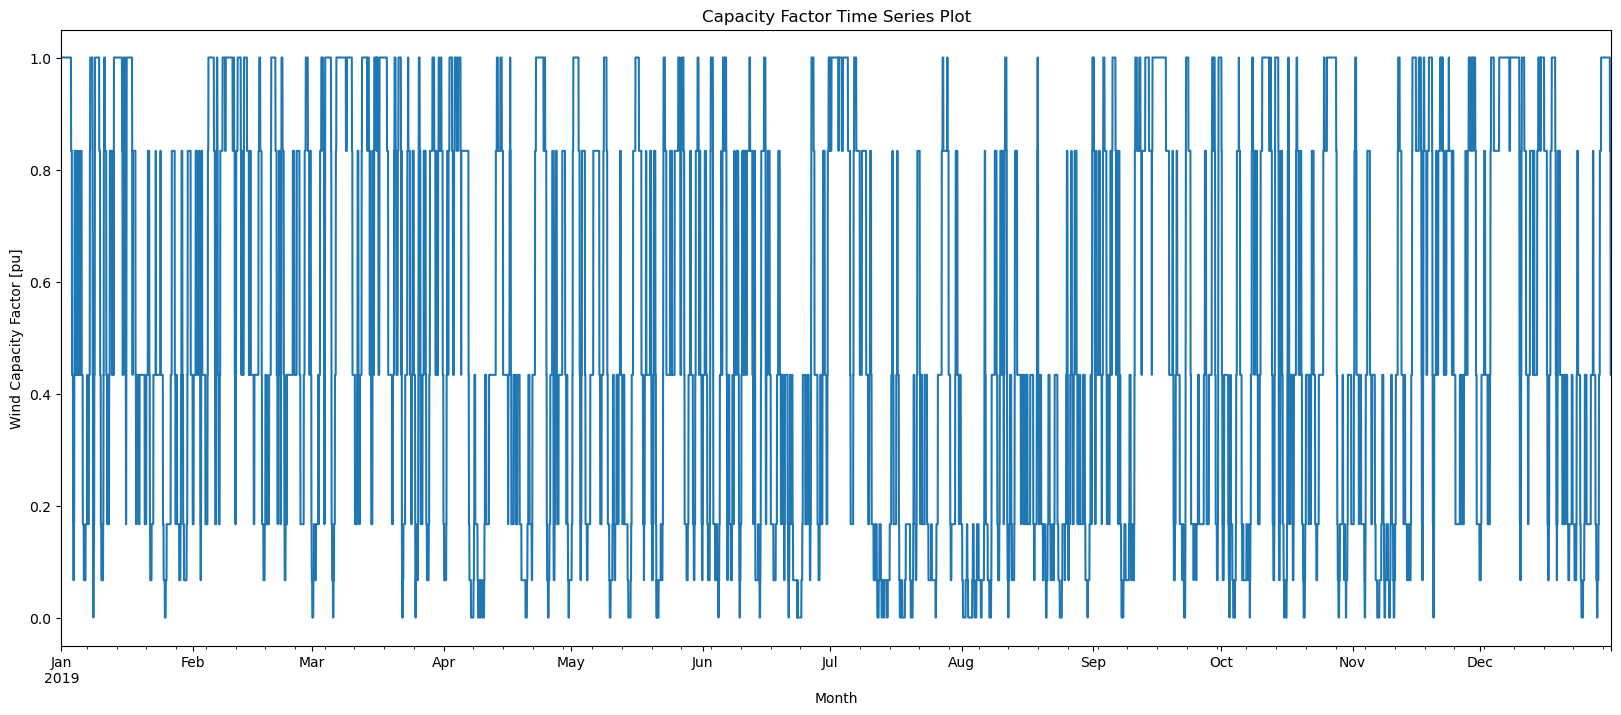

In [17]:
plt.figure(figsize=(20, 8))
ws['Vestas_CF'].plot()
plt.title('Capacity Factor Time Series Plot')
plt.xlabel('Month')
plt.ylabel('Wind Capacity Factor [pu]')
plt.show()

## (II) Time Series Analysis

Investigation of renewable energy in Germany in 2015 considering: Wind, Solar, Demand / Load and Price time series

Inputs:
1. Electricity demand from OPSD in GW
2. Onshore wind capacity factors from renewables.ninja in per-unit of installed capacity
3. Offshore wind capacity factors from renewables.ninja in per-unit of installed capacity
4. Solar PV capacity factors from renewables.ninja in per-unit of installed capacity
5. Electricity day-ahead spot market prices in €/MWh from EPEX Spot zone DE/AT/LU retrieved via SMARD platform

#### Statistics

In [16]:
# Read time series into pandas dataframe
url_ts = 'https://tubcloud.tu-berlin.de/s/nwCrNLrtL6LAN3W/download/time-series-lecture-2.csv'
ts = pd.read_csv(url_ts, parse_dates = True, index_col = 0)
ts.head()

,load [GW],onwind [pu],offwind [pu],solar [pu],prices [€/MWh]
2015-01-01 00:00:00,41.151,0.1566,0.7030,0.0,NaN
2015-01-01 01:00:00,40.135,0.1659,0.6875,0.0,NaN
2015-01-01 02:00:00,39.106,0.1746,0.6535,0.0,NaN
2015-01-01 03:00:00,38.765,0.1745,0.6803,0.0,NaN
2015-01-01 04:00:00,38.941,0.1826,0.7272,0.0,NaN


In [17]:
# Calculate require dstatistics
stats = pd.DataFrame({"Mean" : ts.mean(), "Minimum" : ts.min(), "Maximum" : ts.max(), "Standard Deviation" : ts.std()}).round(4).T
stats

,load [GW],onwind [pu],offwind [pu],solar [pu],prices [€/MWh]
Mean,54.7370,0.2056,0.3630,0.1226,31.8357
Minimum,32.4180,0.0007,0.0000,0.0000,-79.9400
Maximum,75.8170,0.9659,0.9856,0.8134,99.7700
Standard Deviation,9.8901,0.1896,0.2927,0.1826,12.4822


In [18]:
# Calculate column with highest stabdard deviation
print(f"The {stats.T['Standard Deviation'].idxmax()} column has the highest standard deviation")

The prices [€/MWh] column has the highest standard deviation


#### Timestamps with missing data

In [19]:
print(f"There are {len(ts[ts.isna().any(axis=1)])} timestamps with missing data shown below:\n{ts[ts.isna().any(axis=1)].index}")

There are 97 timestamps with missing data shown below:
DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               '2015-01-01 10:00:00', '2015-01-01 11:00:00',
               '2015-01-01 12:00:00', '2015-01-01 13:00:00',
               '2015-01-01 14:00:00', '2015-01-01 15:00:00',
               '2015-01-01 16:00:00', '2015-01-01 17:00:00',
               '2015-01-01 18:00:00', '2015-01-01 19:00:00',
               '2015-01-01 20:00:00', '2015-01-01 21:00:00',
               '2015-01-01 22:00:00', '2015-01-01 23:00:00',
               '2015-01-02 00:00:00', '2015-01-02 01:00:00',
               '2015-01-02 02:00:00', '2015-01-02 03:00:00',
               '2015-01-02 04:00:00', '2015-01-02 05:00:00',
               '2015-01-02 06:

#### Fill missing data with values observed six days ahead

In [ ]:
# Convert the observed values to hours
six_day_ahead = 24*6
import math
for i in range(len(ts['prices [€/MWh]'])):
    if math.isnan(ts['prices [€/MWh]'].iloc[i]):
        ts['prices [€/MWh]'].iloc[i] = ts['prices [€/MWh]'].iloc[i+six_day_ahead]

# Check accuracy of the filled missing values
check_fill = ts.loc['2015-01-01 00:00:00', 'prices [€/MWh]'] == ts.loc['2015-01-07 00:00:00','prices [€/MWh]']
if check_fill:
    print("The missing values have been filled accurately")
else:
    print("Inaccurate filling, check code")

ts.head()

In [21]:
# Check for NA values
missing_values =  ts[ts.isna().any(axis=1)]
if len(missing_values) == 0:
    print("There are no more missing values in the dataframe.")
else:
    print("The dataframe still has missing vlaues.")

There are no more missing values in the dataframe.


#### Plot hourly time series - Year

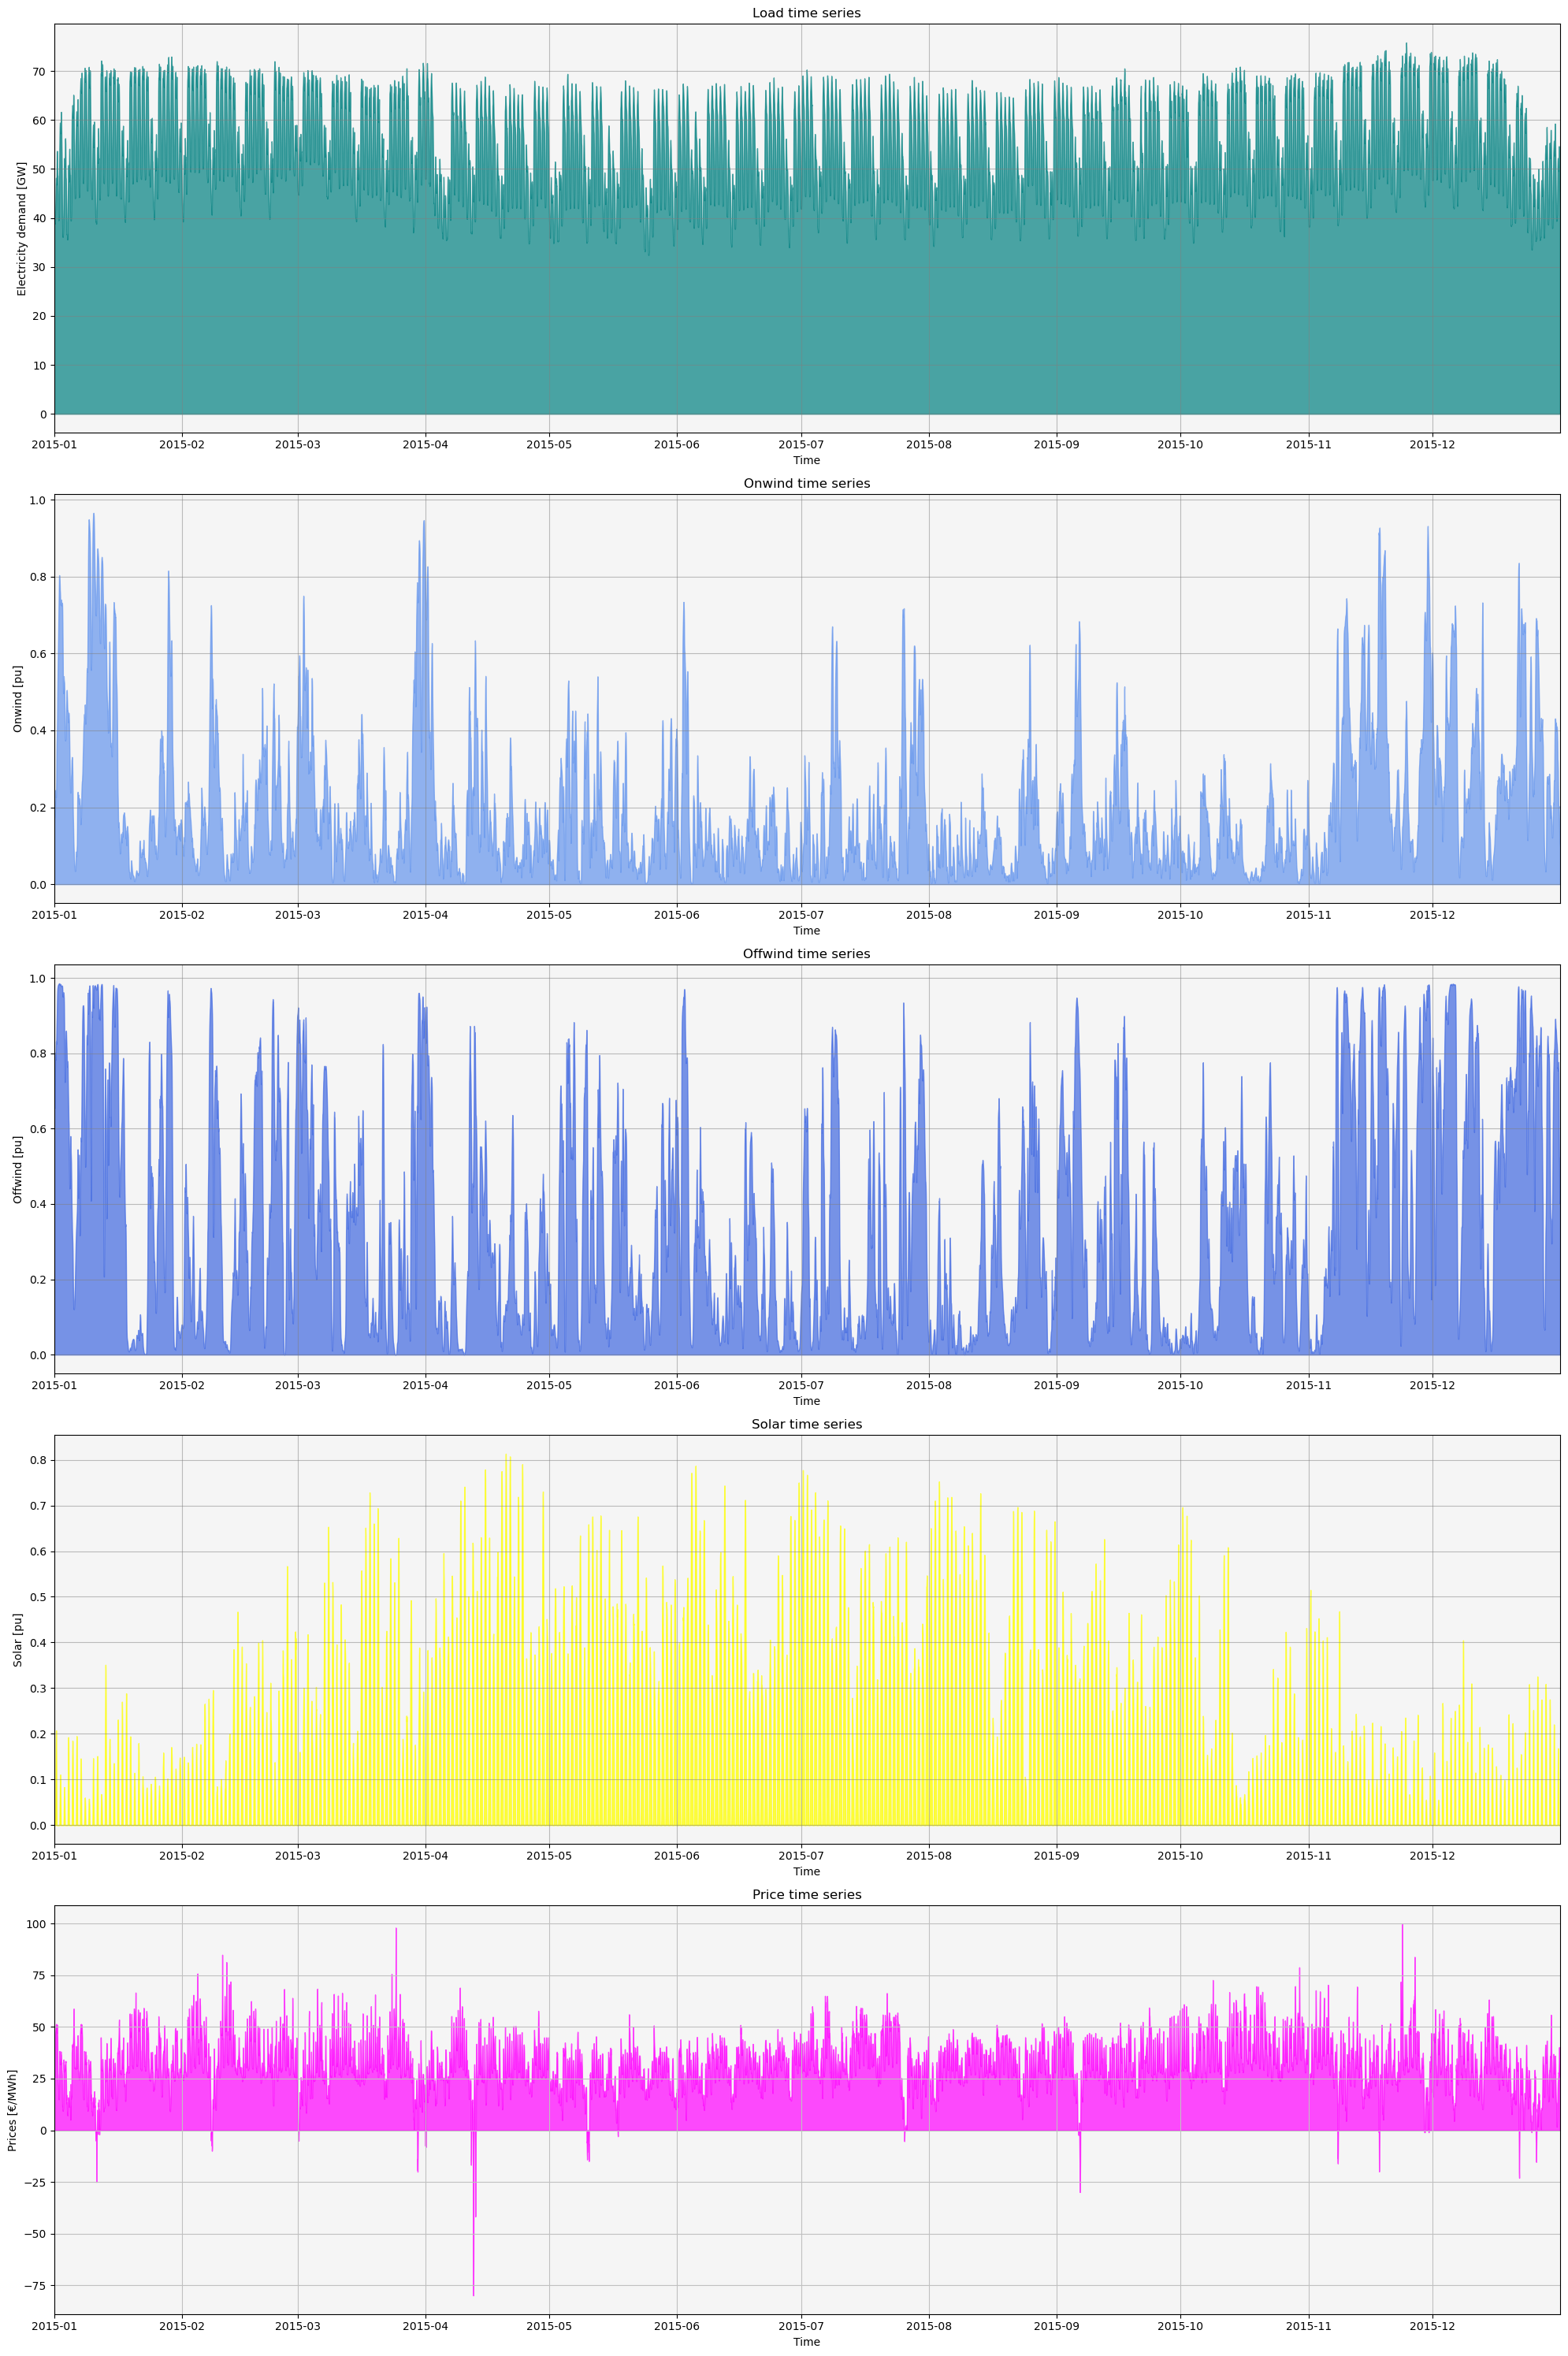

In [22]:
fig, axes = plt.subplots(5,1,figsize=(20, 30))

axes[0].fill_between(ts['load [GW]'].loc['2015'].index,ts['load [GW]'].loc['2015'], color='teal', alpha=0.7)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Electricity demand [GW]')
axes[0].set_title('Load time series')
axes[0].set_facecolor('whitesmoke')
axes[0].grid(color = 'gray', alpha = 0.5)
axes[0].set_xlim(ts.index.min(), ts.index.max())

axes[1].fill_between(ts['onwind [pu]'].loc['2015'].index,ts['onwind [pu]'].loc['2015'], color='cornflowerblue', alpha=0.7)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Onwind [pu]')
axes[1].set_title('Onwind time series')
axes[1].set_facecolor('whitesmoke')
axes[1].grid(color = 'gray', alpha = 0.5)
axes[1].set_xlim(ts.index.min(), ts.index.max())

axes[2].fill_between(ts['offwind [pu]'].loc['2015'].index,ts['offwind [pu]'].loc['2015'], color='royalblue', alpha=0.7)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Offwind [pu]')
axes[2].set_title('Offwind time series')
axes[2].set_facecolor('whitesmoke')
axes[2].grid(color = 'gray', alpha = 0.5)
axes[2].set_xlim(ts.index.min(), ts.index.max())

axes[3].fill_between(ts['solar [pu]'].loc['2015'].index,ts['solar [pu]'].loc['2015'], color='yellow', alpha=0.7)
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Solar [pu]')
axes[3].set_title('Solar time series')
axes[3].set_facecolor('whitesmoke')
axes[3].grid(color = 'gray', alpha = 0.5)
axes[3].set_xlim(ts.index.min(), ts.index.max())

axes[4].fill_between(ts['prices [€/MWh]'].loc['2015'].index,ts['prices [€/MWh]'].loc['2015'], color='magenta', alpha=0.7)
axes[4].set_xlabel('Time')
axes[4].set_ylabel('Prices [€/MWh]')
axes[4].set_title('Price time series')
axes[4].set_facecolor('whitesmoke')
axes[4].grid(color = 'silver')
axes[4].set_xlim(ts.index.min(), ts.index.max())


fig.tight_layout()
plt.show()

#### Plot hourly time series - Month

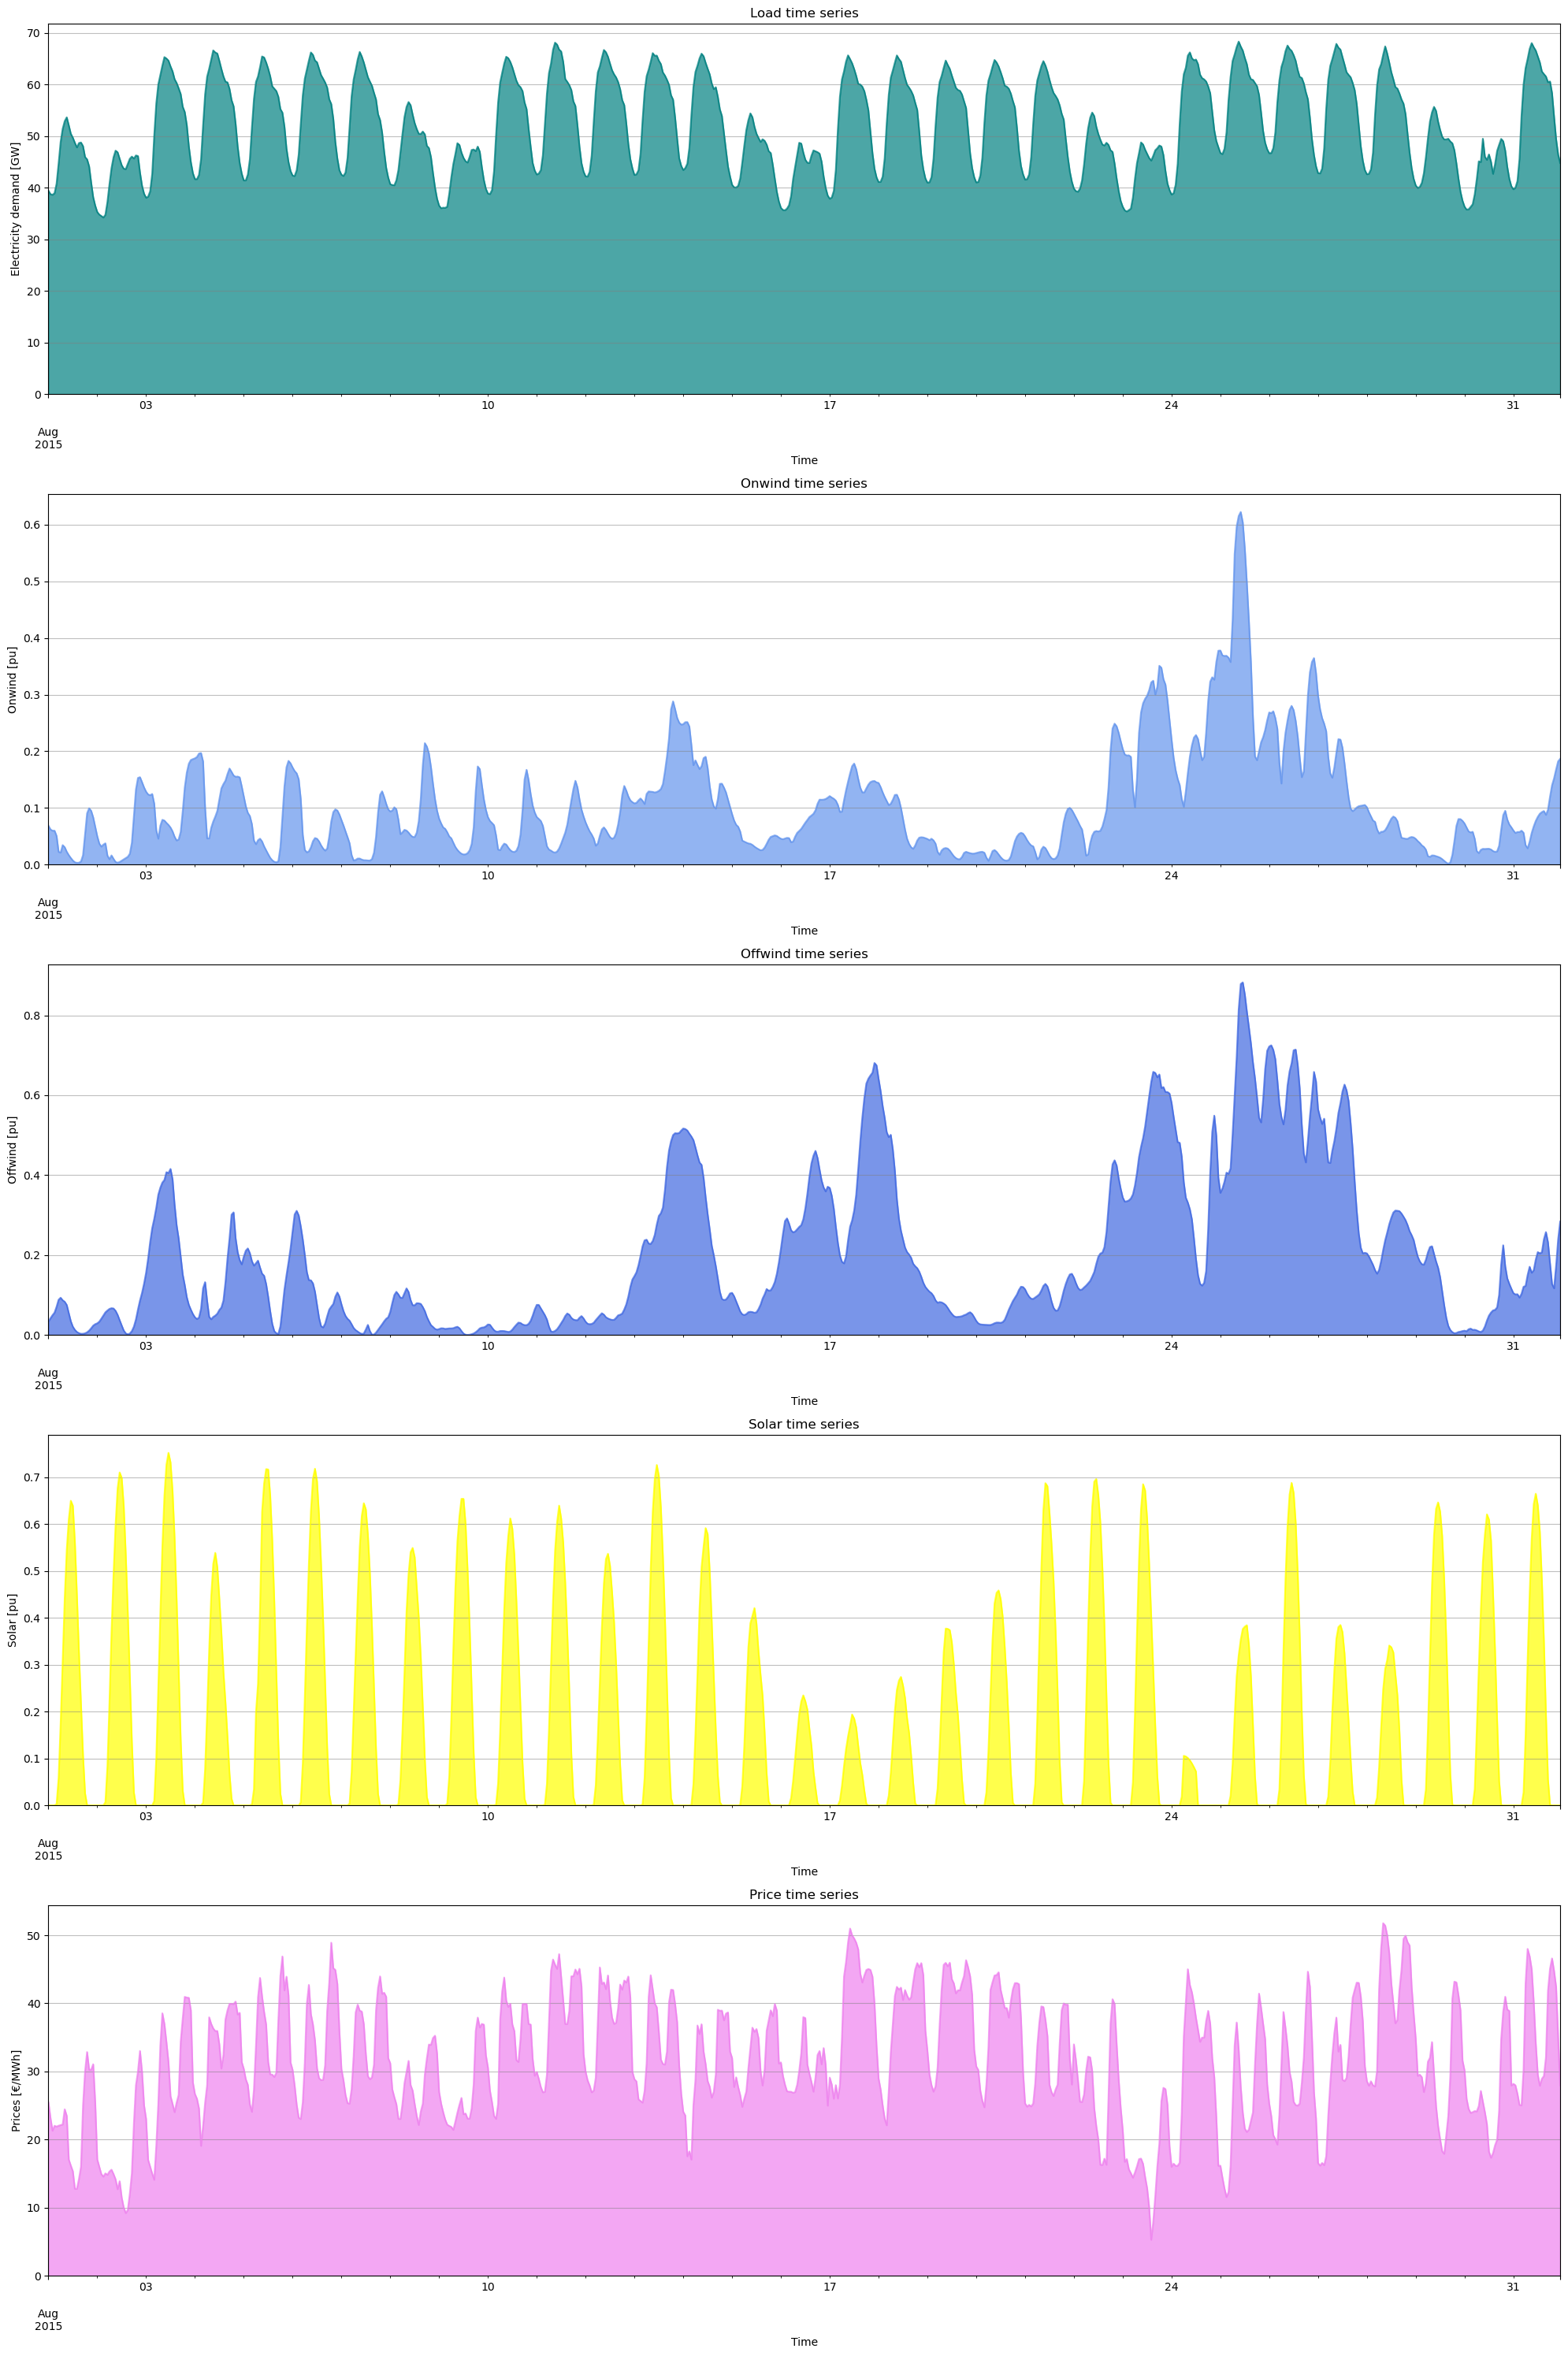

In [23]:
fig, axes = plt.subplots(5,1,figsize=(20, 30))

ts.loc['2015-8','load [GW]'].plot.area(ax=axes[0], color = 'teal',alpha = 0.7)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Electricity demand [GW]')
axes[0].set_title('Load time series')
axes[0].grid(color = 'gray', alpha = 0.5)

ts.loc['2015-8','onwind [pu]'].plot.area(ax=axes[1], color = 'cornflowerblue',alpha = 0.7)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Onwind [pu]')
axes[1].set_title('Onwind time series')
axes[1].grid(color = 'gray', alpha = 0.5)

ts.loc['2015-8','offwind [pu]'].plot.area(ax=axes[2], color = 'royalblue',alpha = 0.7)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Offwind [pu]')
axes[2].set_title('Offwind time series')
axes[2].grid(color = 'gray', alpha = 0.5)

ts.loc['2015-8','solar [pu]'].plot.area(ax=axes[3], color = 'yellow',alpha = 0.7)
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Solar [pu]')
axes[3].set_title('Solar time series')
axes[3].grid(color = 'gray', alpha = 0.5)



ts.loc['2015-8','prices [€/MWh]'].plot.area(ax=axes[4], color = 'violet',alpha = 0.7)
axes[4].set_xlabel('Time')
axes[4].set_ylabel('Prices [€/MWh]')
axes[4].set_title('Price time series')
axes[4].grid(color = 'gray', alpha = 0.5)


fig.tight_layout()
plt.show()

#### Daily, Weekly and Monthly resampled time series plot

In [24]:
ts['prices [€/MWh]'].loc['2015']

2015-01-01 00:00:00    24.97
2015-01-01 01:00:00    24.65
2015-01-01 02:00:00    24.68
2015-01-01 03:00:00    25.06
2015-01-01 04:00:00    26.10
                       ...  
2015-12-31 19:00:00    36.79
2015-12-31 20:00:00    28.81
2015-12-31 21:00:00    26.27
2015-12-31 22:00:00    29.99
2015-12-31 23:00:00    31.59
Name: prices [€/MWh], Length: 8760, dtype: float64

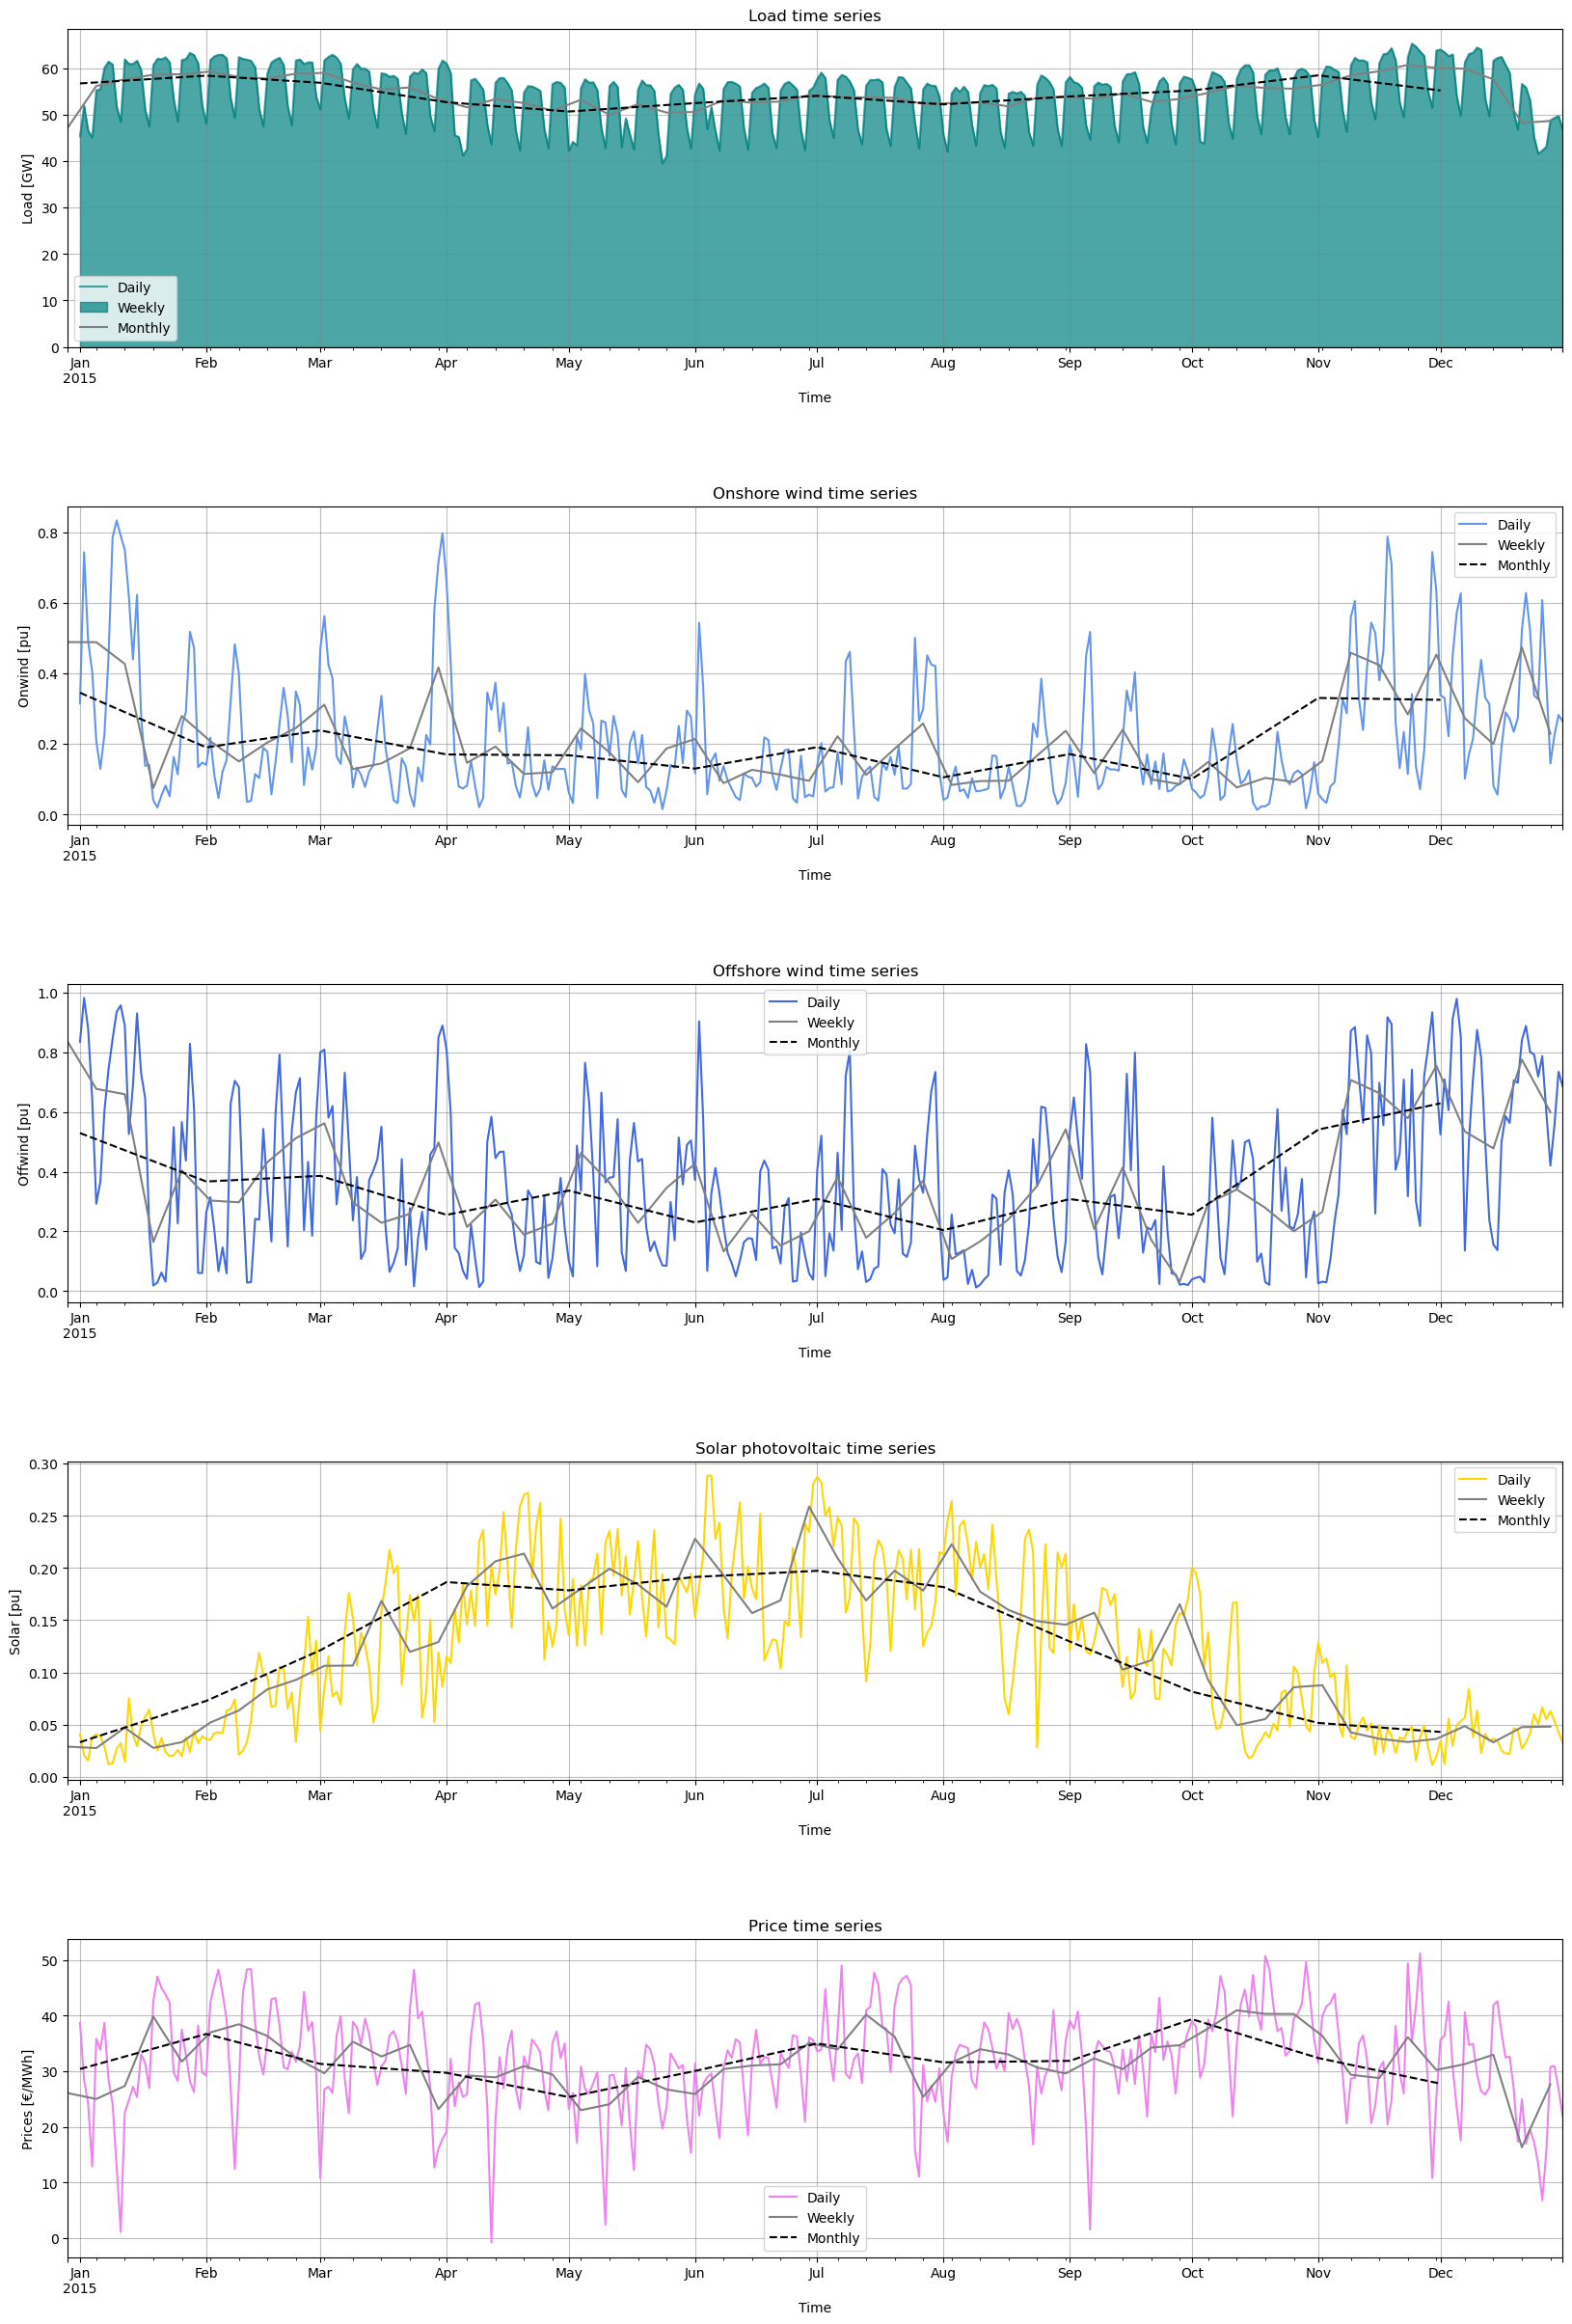

In [25]:
fig, axes = plt.subplots(5, 1, figsize=(20,30))

'''axes[0].fill_between(ts['load [GW]'].loc['2015'].index,ts['load [GW]'].loc['2015'], color='teal', alpha=0.7)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Electricity demand [GW]')
axes[0].set_title('Load time series')
axes[0].set_facecolor('whitesmoke')
axes[0].grid(color = 'gray', alpha = 0.5)
axes[0].set_xlim(ts.index.min(), ts.index.max())'''

ts.loc["2015", ['load [GW]']].resample("D").mean().plot.area(ax=axes[0],grid = 'black', color = 'teal', alpha = 0.7)
ts.loc["2015", ['load [GW]']].resample("W").mean().plot(ax=axes[0],grid = 'black', color  = 'grey' )
ts.loc["2015", ['load [GW]']].resample("ME").mean().plot(ax=axes[0],grid = 'black', color = 'black', linestyle = '--' )
axes[0].set_title("Load time series")
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Load [GW]')
axes[0].legend(['Daily','Weekly','Monthly'])
axes[0].grid(color = 'gray', alpha = 0.5)


ts.loc["2015", ['onwind [pu]']].resample("D").mean().plot(ax=axes[1],grid = 'black', color = 'cornflowerblue')
ts.loc["2015", ['onwind [pu]']].resample("W").mean().plot(ax=axes[1],grid = 'black',color = 'grey')
ts.loc["2015", ['onwind [pu]']].resample("ME").mean().plot(ax=axes[1],grid = 'black',color = 'black', linestyle = '--')
axes[1].set_title("Onshore wind time series")
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Onwind [pu]')
axes[1].legend(['Daily','Weekly','Monthly'])
axes[1].grid(color = 'gray', alpha = 0.5)

ts.loc["2015", ['offwind [pu]']].resample("D").mean().plot(ax=axes[2],grid = 'black', color = 'royalblue')
ts.loc["2015", ['offwind [pu]']].resample("W").mean().plot(ax=axes[2],grid = 'black', color = 'grey')
ts.loc["2015", ['offwind [pu]']].resample("ME").mean().plot(ax=axes[2],grid = 'black', color = 'black', linestyle = '--')
axes[2].set_title("Offshore wind time series")
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Offwind [pu]')
axes[2].legend(['Daily','Weekly','Monthly'])
axes[2].grid(color = 'gray', alpha = 0.5)

ts.loc["2015", ['solar [pu]']].resample("D").mean().plot(ax=axes[3],grid = 'black', color = 'gold')
ts.loc["2015", ['solar [pu]']].resample("W").mean().plot(ax=axes[3],grid = 'black', color = 'grey')
ts.loc["2015", ['solar [pu]']].resample("ME").mean().plot(ax=axes[3],grid = 'black', color = 'black', linestyle = '--')
axes[3].set_title("Solar photovoltaic time series")
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Solar [pu]')
axes[3].legend(['Daily','Weekly','Monthly'])
axes[3].grid(color = 'gray', alpha = 0.5)

ts.loc["2015", ['prices [€/MWh]']].resample("D").mean().plot(ax=axes[4],grid = 'black', color = 'violet')
ts.loc["2015", ['prices [€/MWh]']].resample("W").mean().plot(ax=axes[4],grid = 'black', color = 'grey')
ts.loc["2015", ['prices [€/MWh]']].resample("ME").mean().plot(ax=axes[4],grid = 'black', color = 'black', linestyle = '--')
axes[4].set_title("Price time series")
axes[4].set_xlabel('Time')
axes[4].set_ylabel('Prices [€/MWh]')
axes[4].legend(['Daily','Weekly','Monthly'])
axes[4].grid(color = 'gray', alpha = 0.5)


plt.subplots_adjust(hspace=0.5)

#fig.tight_layout()
plt.show() 

#### Duration Curves

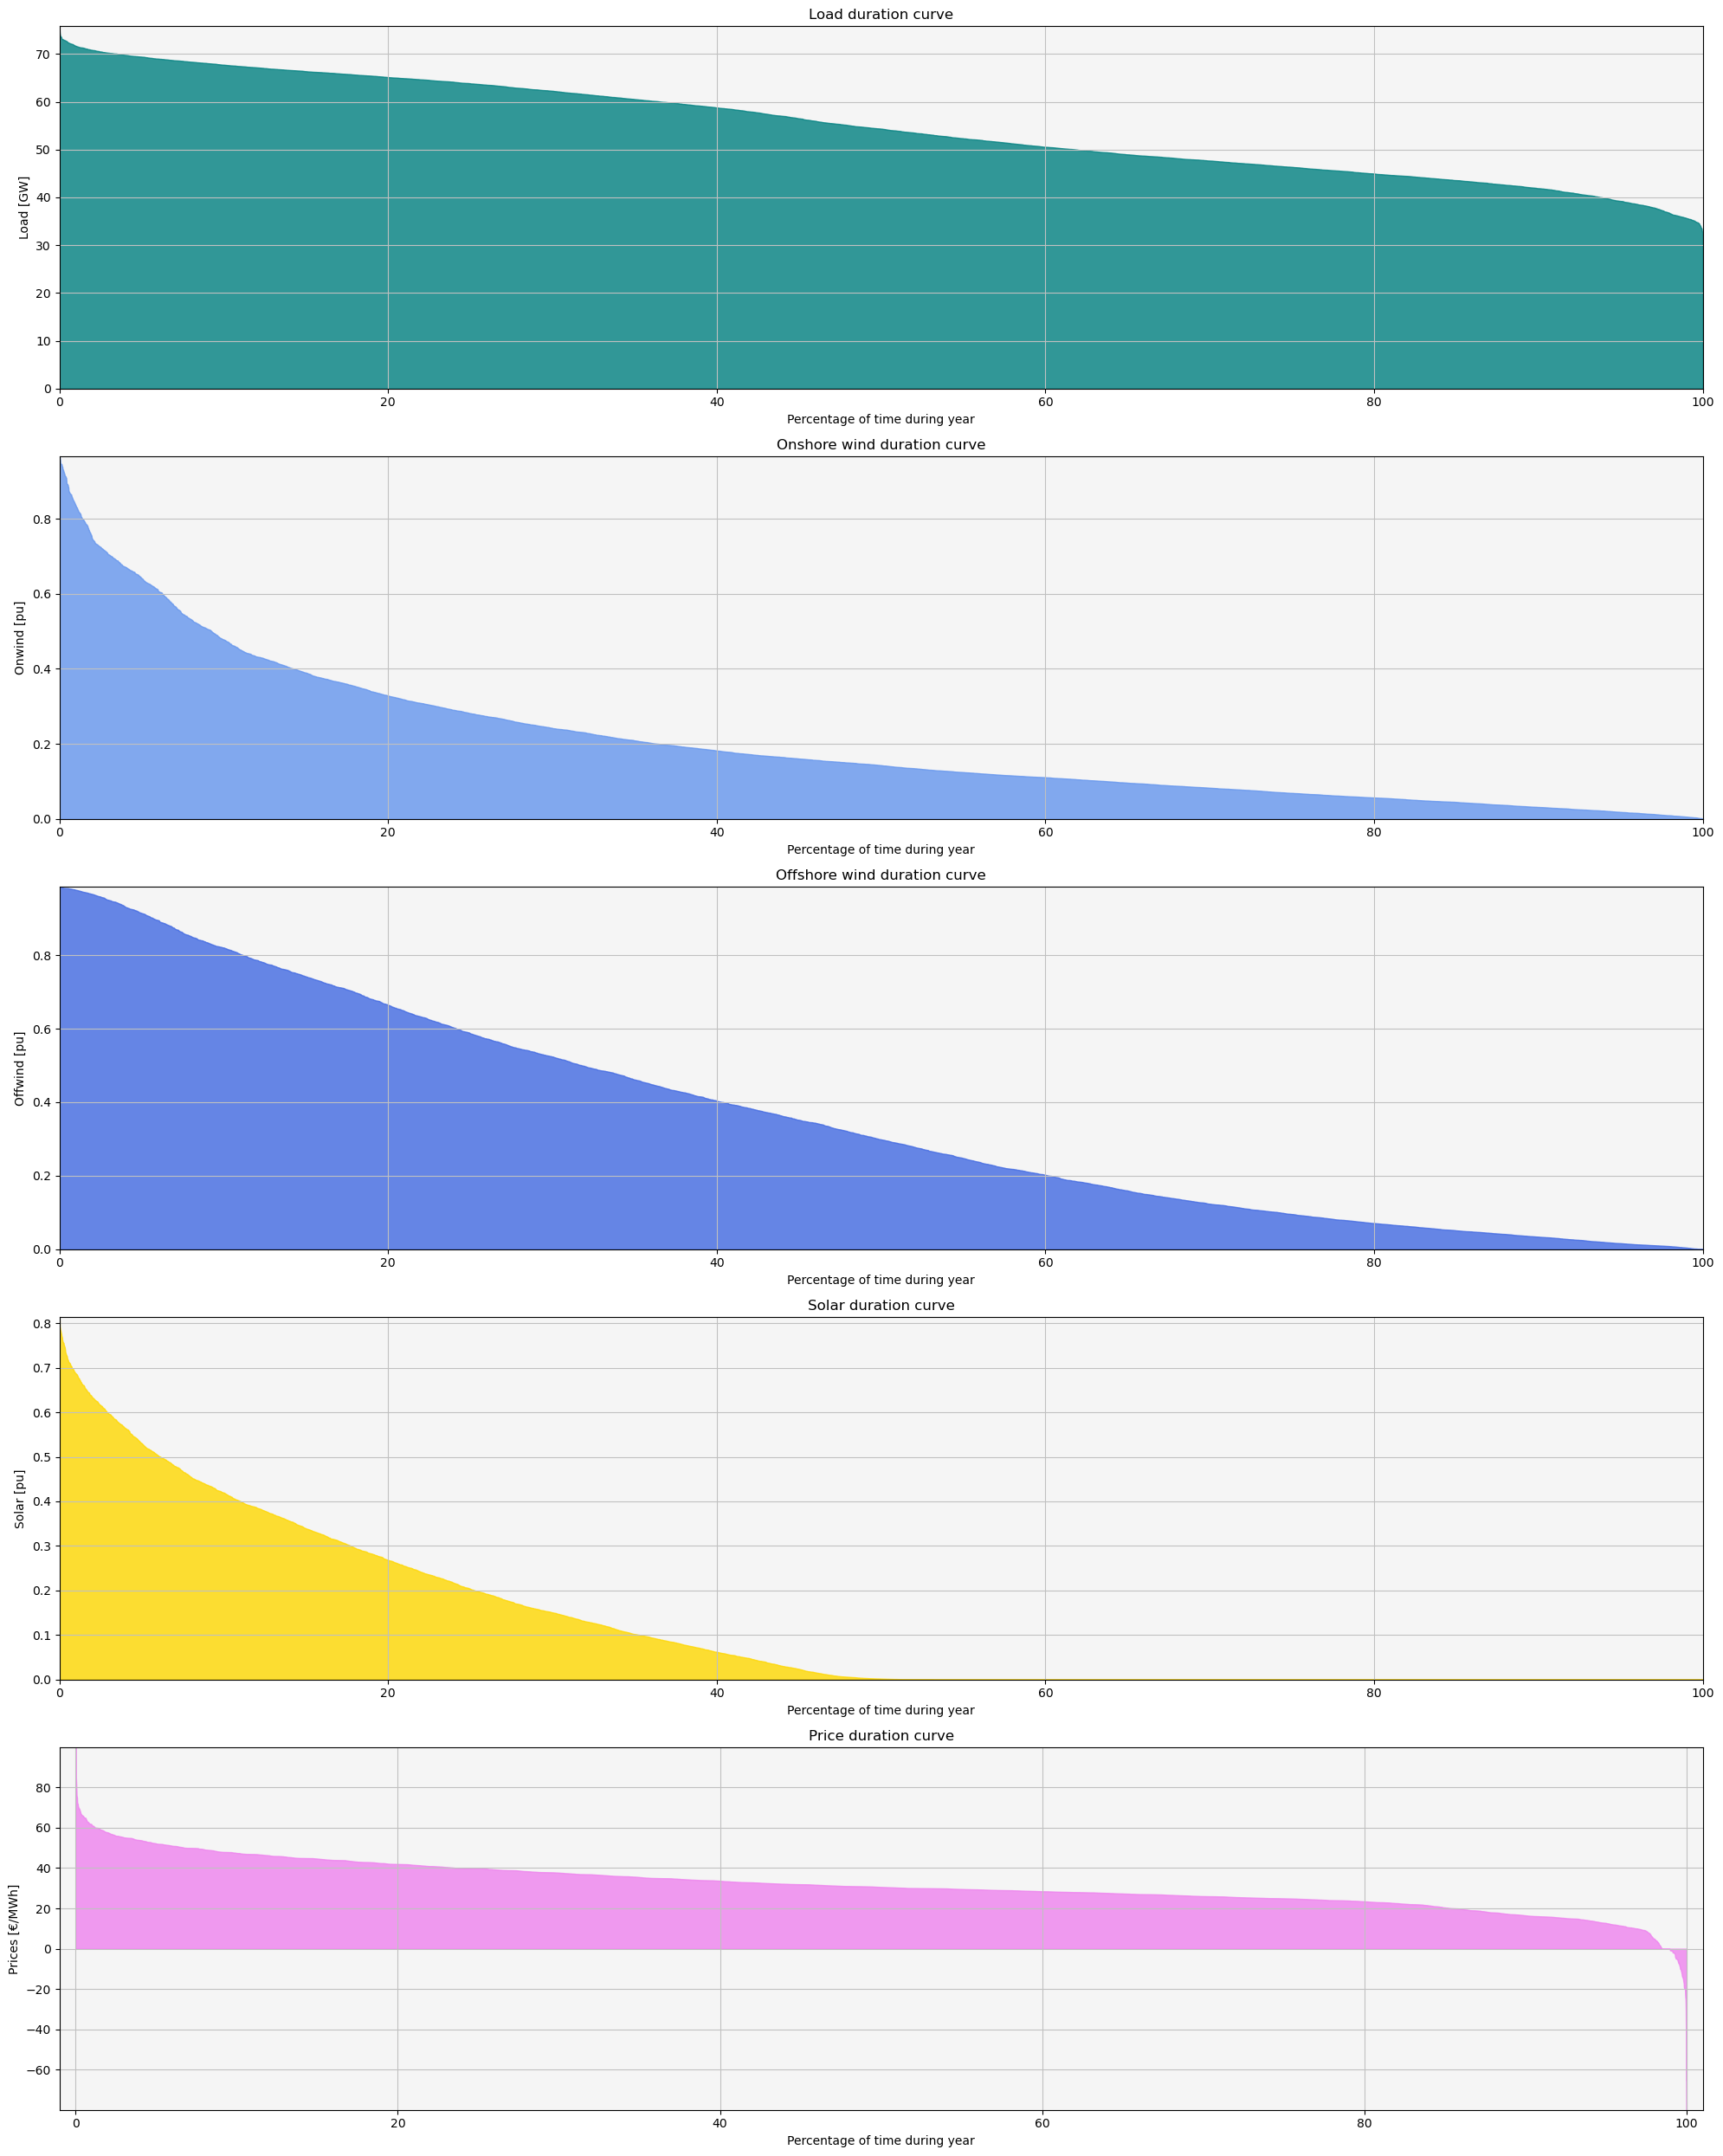

In [26]:
fig, axes = plt.subplots(5, 1, figsize=(20,25))

load_sorted = ts['load [GW]'].loc['2015'].sort_values(ascending=False).reset_index(drop=True)
load_percentage = load_sorted.index/len(load_sorted)*100
axes[0].fill_between(load_percentage, load_sorted, color='teal', alpha=0.8)
axes[0].set_title("Load duration curve")
axes[0].set_xlabel('Percentage of time during year')
axes[0].set_ylabel('Load [GW]')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, load_sorted.max())
axes[0].set_facecolor('whitesmoke')
axes[0].grid(color = 'silver')


onwind_sorted = ts['onwind [pu]'].loc['2015'].sort_values(ascending=False).reset_index(drop=True)
onwind_percentage = onwind_sorted.index/len(onwind_sorted)*100
axes[1].fill_between(onwind_percentage, onwind_sorted, color='cornflowerblue', alpha=0.8)
axes[1].set_title("Onshore wind duration curve")
axes[1].set_xlabel('Percentage of time during year')
axes[1].set_ylabel('Onwind [pu]')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, onwind_sorted.max())
axes[1].set_facecolor('whitesmoke')
axes[1].grid(color = 'silver')


offwind_sorted = ts['offwind [pu]'].loc['2015'].sort_values(ascending=False).reset_index(drop=True)
offwind_percentage = offwind_sorted.index/len(offwind_sorted)*100
axes[2].fill_between(offwind_percentage, offwind_sorted, color='royalblue', alpha=0.8)
axes[2].set_title("Offshore wind duration curve")
axes[2].set_xlabel('Percentage of time during year')
axes[2].set_ylabel('Offwind [pu]')
axes[2].set_xlim(0, 100)
axes[2].set_ylim(0, offwind_sorted.max())
axes[2].set_facecolor('whitesmoke')
axes[2].grid(color = 'silver')


solar_sorted = ts['solar [pu]'].loc['2015'].sort_values(ascending=False).reset_index(drop=True)
solar_percentage = solar_sorted.index/len(solar_sorted)*100
axes[3].fill_between(solar_percentage, solar_sorted, color='gold', alpha=0.8)
axes[3].set_title("Solar duration curve")
axes[3].set_xlabel('Percentage of time during year')
axes[3].set_ylabel('Solar [pu]')
axes[3].set_xlim(0, 100)
axes[3].set_ylim(0, solar_sorted.max())
axes[3].set_facecolor('whitesmoke')
axes[3].grid(color = 'silver')


prices_sorted = ts['prices [€/MWh]'].loc['2015'].sort_values(ascending=False).reset_index(drop=True)
prices_percentage = prices_sorted.index/len(prices_sorted)*100
axes[4].fill_between(prices_percentage, prices_sorted, color='violet', alpha=0.8)
axes[4].set_title("Price duration curve")
axes[4].set_xlabel('Percentage of time during year')
axes[4].set_ylabel('Prices [€/MWh]')
axes[4].set_xlim(-1, 101)
axes[4].set_ylim(prices_sorted.min(), prices_sorted.max())
axes[4].set_facecolor('whitesmoke')
axes[4].grid(color = 'silver')

plt.subplots_adjust(hspace=0.5)

fig.tight_layout()
plt.show() 

#### Fourier Transform

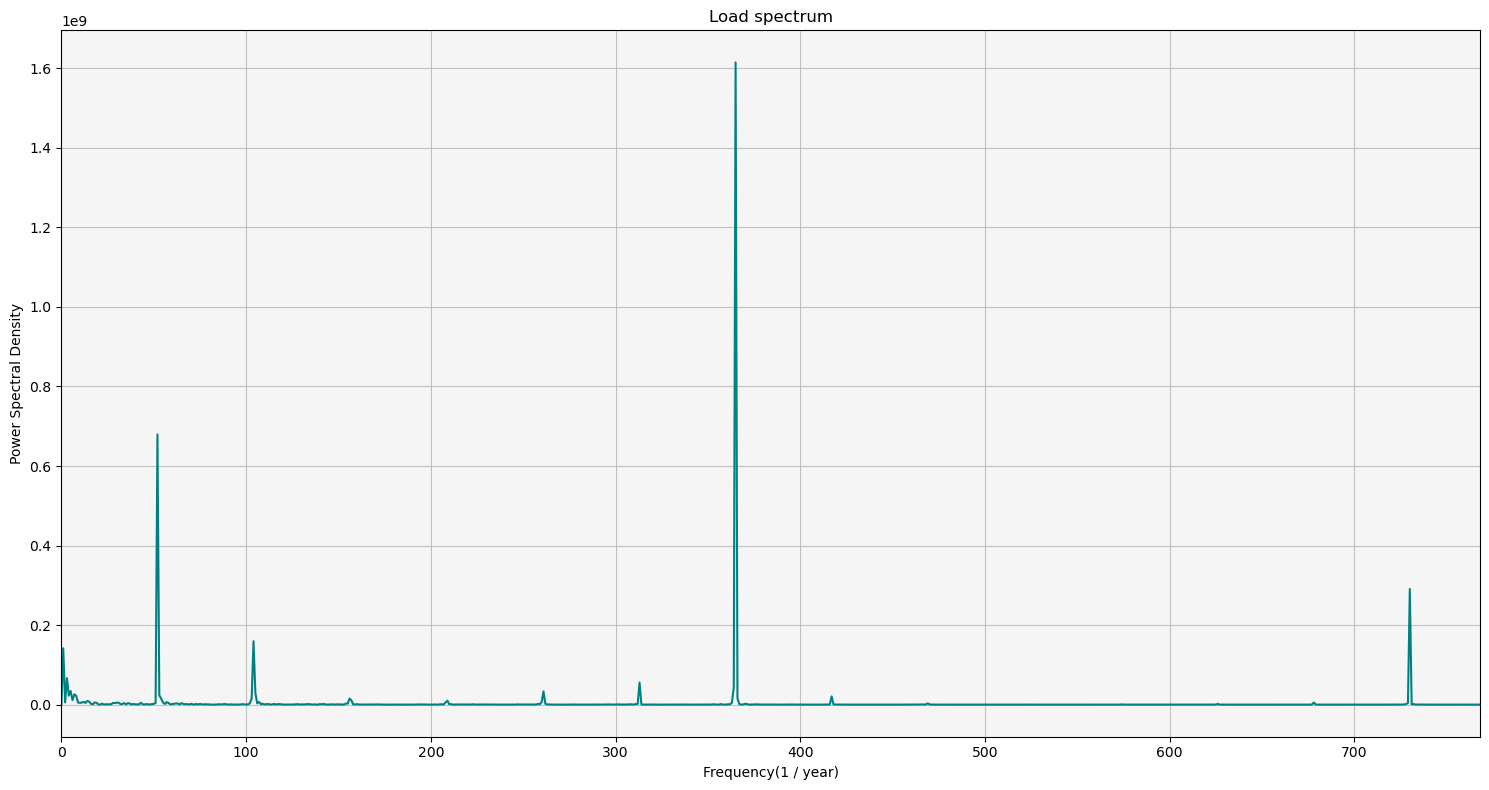

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    
ft_load = abs(pd.Series(np.fft.rfft(ts['load [GW]']- ts['load [GW]'].mean()), index=np.fft.rfftfreq(len(ts['load [GW]']), d=1./8760))**2)
ft_load.plot(ax=ax,color="teal")
ax.set_xlim(0, 768)
ax.set_title('Load spectrum')
ax.set_xlabel('Frequency(1 / year)')
ax.set_ylabel('Power Spectral Density')
ax.set_facecolor('whitesmoke')
ax.grid(color = 'silver')

fig.tight_layout()
plt.show() 

#### Cause of the distinct peaks
The peaks occur approximately: 

 - 52 times per year : caused by weekends and weekdays
 - 104 times per year : caused by holidays
 - 365 times per year : caused by the daily cycle of activities, day peaks in both residential and industrial sectors 
 - 730 times per year : caused by morning and evening peaks
    

## (III) Solar Power in the World

Exploration of the Global Solar Power Tracker published by the Global Energy Monitor with a focus on the global utility-scale solar photovoltaic (PV) and solar thermal facilities<br>
Source: https://globalenergymonitor.org/projects/global-solar-power-tracker/

#### Read excel file into pandas and convert to GeoDataFrame

In [28]:
import geopandas as gpd
import cartopy
import cartopy.crs as ccrs

In [29]:
url_pv = "https://tubcloud.tu-berlin.de/s/rwygB8sbmzxSRk5/download/Global-Solar-Power-Tracker-May-2023.xlsx"
pv = pd.ExcelFile(url_pv)

# Check Sheet Names
pv.sheet_names

['About', 'Data', 'Below Threshold']

In [30]:
# Use sheet name with Data
pv = pd.read_excel(url_pv, sheet_name='Data', parse_dates = True)
pv.head()

,Date Last Researched,Country,Project Name,Phase Name,Project Name in Local Language / Script,Other Name(s),Capacity (MW),Capacity Rating,Technology Type,Status,...,"Local area (taluk, county)","Major area (prefecture, district)",State/Province,Subregion,Region,GEM location ID,GEM phase ID,Other IDs (location),Other IDs (unit/phase),Wiki URL
0,2022-08-16,Algeria,Adrar Solar Plant,NaN,NaN,NaN,20.0,MWp/dc,PV,operating,...,Adrar District,NaN,Adrar,Northern Africa,Africa,L800008,G800008,WRI: WKS0068905,NaN,https://gem.wiki/Adrar_Solar_Plant
1,2022-08-16,Algeria,Ain Azel solar farm,NaN,محطة توليد الكهرباء بعين زادة,NaN,20.0,unknown,PV,operating,...,Ain Arnat,NaN,Sétif,Northern Africa,Africa,L800010,G800010,WRI: WKS0065285,NaN,https://gem.wiki/Ain_Azel_solar_farm
2,2022-08-16,Algeria,Ain El Ibel Solar,PV 1,محطة عين الابل للطاقة الشمسية ١,Ain Albel 1 solar plant,20.0,unknown,PV,operating,...,Aïn El Ibel District,NaN,Djelfa,Northern Africa,Africa,L800012,G800012,WRI: WKS0068916,NaN,https://gem.wiki/Ain_El_Ibel_Solar
3,2022-08-16,Algeria,Ain El Ibel Solar,PV 2,محطة عين الابل للطاقة الشمسية ٢,Ain Albel 2 solar plant,33.0,unknown,PV,operating,...,Aïn El Ibel District,NaN,Djelfa,Northern Africa,Africa,L800012,G800013,WRI: WKS0073479,NaN,https://gem.wiki/Ain_El_Ibel_Solar
4,2022-08-16,Algeria,Ain El Mehl Solar,NaN,محطة عين الملح للطاقة الشمسية,Ain El Melh Solar,20.0,unknown,PV,operating,...,Aïn El Melh District,NaN,M'Sila,Northern Africa,Africa,L800013,G800014,WRI: WKS0068915,NaN,https://gem.wiki/Ain_El_Mehl_Solar


In [31]:
# Convert dataframe to geodataframe
geometry = gpd.points_from_xy(pv["Longitude"], pv["Latitude"])
gdf_pv = gpd.GeoDataFrame(pv, geometry=geometry, crs=4326)
gdf_pv.head()

,Date Last Researched,Country,Project Name,Phase Name,Project Name in Local Language / Script,Other Name(s),Capacity (MW),Capacity Rating,Technology Type,Status,...,"Major area (prefecture, district)",State/Province,Subregion,Region,GEM location ID,GEM phase ID,Other IDs (location),Other IDs (unit/phase),Wiki URL,geometry
0,2022-08-16,Algeria,Adrar Solar Plant,NaN,NaN,NaN,20.0,MWp/dc,PV,operating,...,NaN,Adrar,Northern Africa,Africa,L800008,G800008,WRI: WKS0068905,NaN,https://gem.wiki/Adrar_Solar_Plant,POINT (-0.31740 27.90770)
1,2022-08-16,Algeria,Ain Azel solar farm,NaN,محطة توليد الكهرباء بعين زادة,NaN,20.0,unknown,PV,operating,...,NaN,Sétif,Northern Africa,Africa,L800010,G800010,WRI: WKS0065285,NaN,https://gem.wiki/Ain_Azel_solar_farm,POINT (5.33210 36.16110)
2,2022-08-16,Algeria,Ain El Ibel Solar,PV 1,محطة عين الابل للطاقة الشمسية ١,Ain Albel 1 solar plant,20.0,unknown,PV,operating,...,NaN,Djelfa,Northern Africa,Africa,L800012,G800012,WRI: WKS0068916,NaN,https://gem.wiki/Ain_El_Ibel_Solar,POINT (3.16360 34.34470)
3,2022-08-16,Algeria,Ain El Ibel Solar,PV 2,محطة عين الابل للطاقة الشمسية ٢,Ain Albel 2 solar plant,33.0,unknown,PV,operating,...,NaN,Djelfa,Northern Africa,Africa,L800012,G800013,WRI: WKS0073479,NaN,https://gem.wiki/Ain_El_Ibel_Solar,POINT (3.16960 34.34330)
4,2022-08-16,Algeria,Ain El Mehl Solar,NaN,محطة عين الملح للطاقة الشمسية,Ain El Melh Solar,20.0,unknown,PV,operating,...,NaN,M'Sila,Northern Africa,Africa,L800013,G800014,WRI: WKS0068915,NaN,https://gem.wiki/Ain_El_Mehl_Solar,POINT (4.20260 34.85970)


#### Share of Solar thermal and photovoltaics capacity

In [32]:
# Checking the Technology types
gdf_pv['Technology Type'].unique()

array(['PV', 'Solar Thermal', 'Assumed PV', 'assumed PV'], dtype=object)

In [33]:
# Checking the column names
gdf_pv.columns

Index(['Date Last Researched', 'Country', 'Project Name', 'Phase Name',
       'Project Name in Local Language / Script', 'Other Name(s)',
       'Capacity (MW)', 'Capacity Rating', 'Technology Type', 'Status',
       'Start year', 'Retired year', 'Operator',
       'Operator Name in Local Language / Script', 'Owner',
       'Owner Name in Local Language / Script', 'Latitude', 'Longitude',
       'Location accuracy', 'City', 'Local area (taluk, county)',
       'Major area (prefecture, district)', 'State/Province', 'Subregion',
       'Region', 'GEM location ID', 'GEM phase ID', 'Other IDs (location)',
       'Other IDs (unit/phase)', 'Wiki URL', 'geometry'],
      dtype='object')

In [34]:
# PV Capacity share
# Including Assumed PV
print(f"The photovoltaics share is {gdf_pv[gdf_pv['Technology Type'].str.contains('PV')]['Capacity (MW)'].sum()/gdf_pv['Capacity (MW)'].sum()*100:.2f}% of the total capacity.")

# Excluding Assumed PV
print(f"The photovoltaics share is {gdf_pv[gdf_pv['Technology Type'] == 'PV']['Capacity (MW)'].sum()/gdf_pv['Capacity (MW)'].sum()*100:.2f}% of the total capacity.")

# Solar Thermal Capacity share
print(f"The Solar Thermal share is {gdf_pv[gdf_pv['Technology Type'] == 'Solar Thermal']['Capacity (MW)'].sum()/gdf_pv['Capacity (MW)'].sum()*100:.2f}% of the total capacity.")

The photovoltaics share is 98.34% of the total capacity.
The photovoltaics share is 95.29% of the total capacity.
The Solar Thermal share is 1.66% of the total capacity.


#### New Global Capacity installations (2000 - 2022)

In [35]:
# Remove rows with missing start year 
gdf_pv = gdf_pv[~gdf_pv['Start year'].isna()]

In [36]:
# Sort Date index ascending 
gdf_pv.sort_values("Start year")

# Subset the for years 2000 through 2022
gdf_new = gdf_pv[(gdf_pv['Start year'] >= 2000) & (gdf_pv['Start year'] <= 2022)]

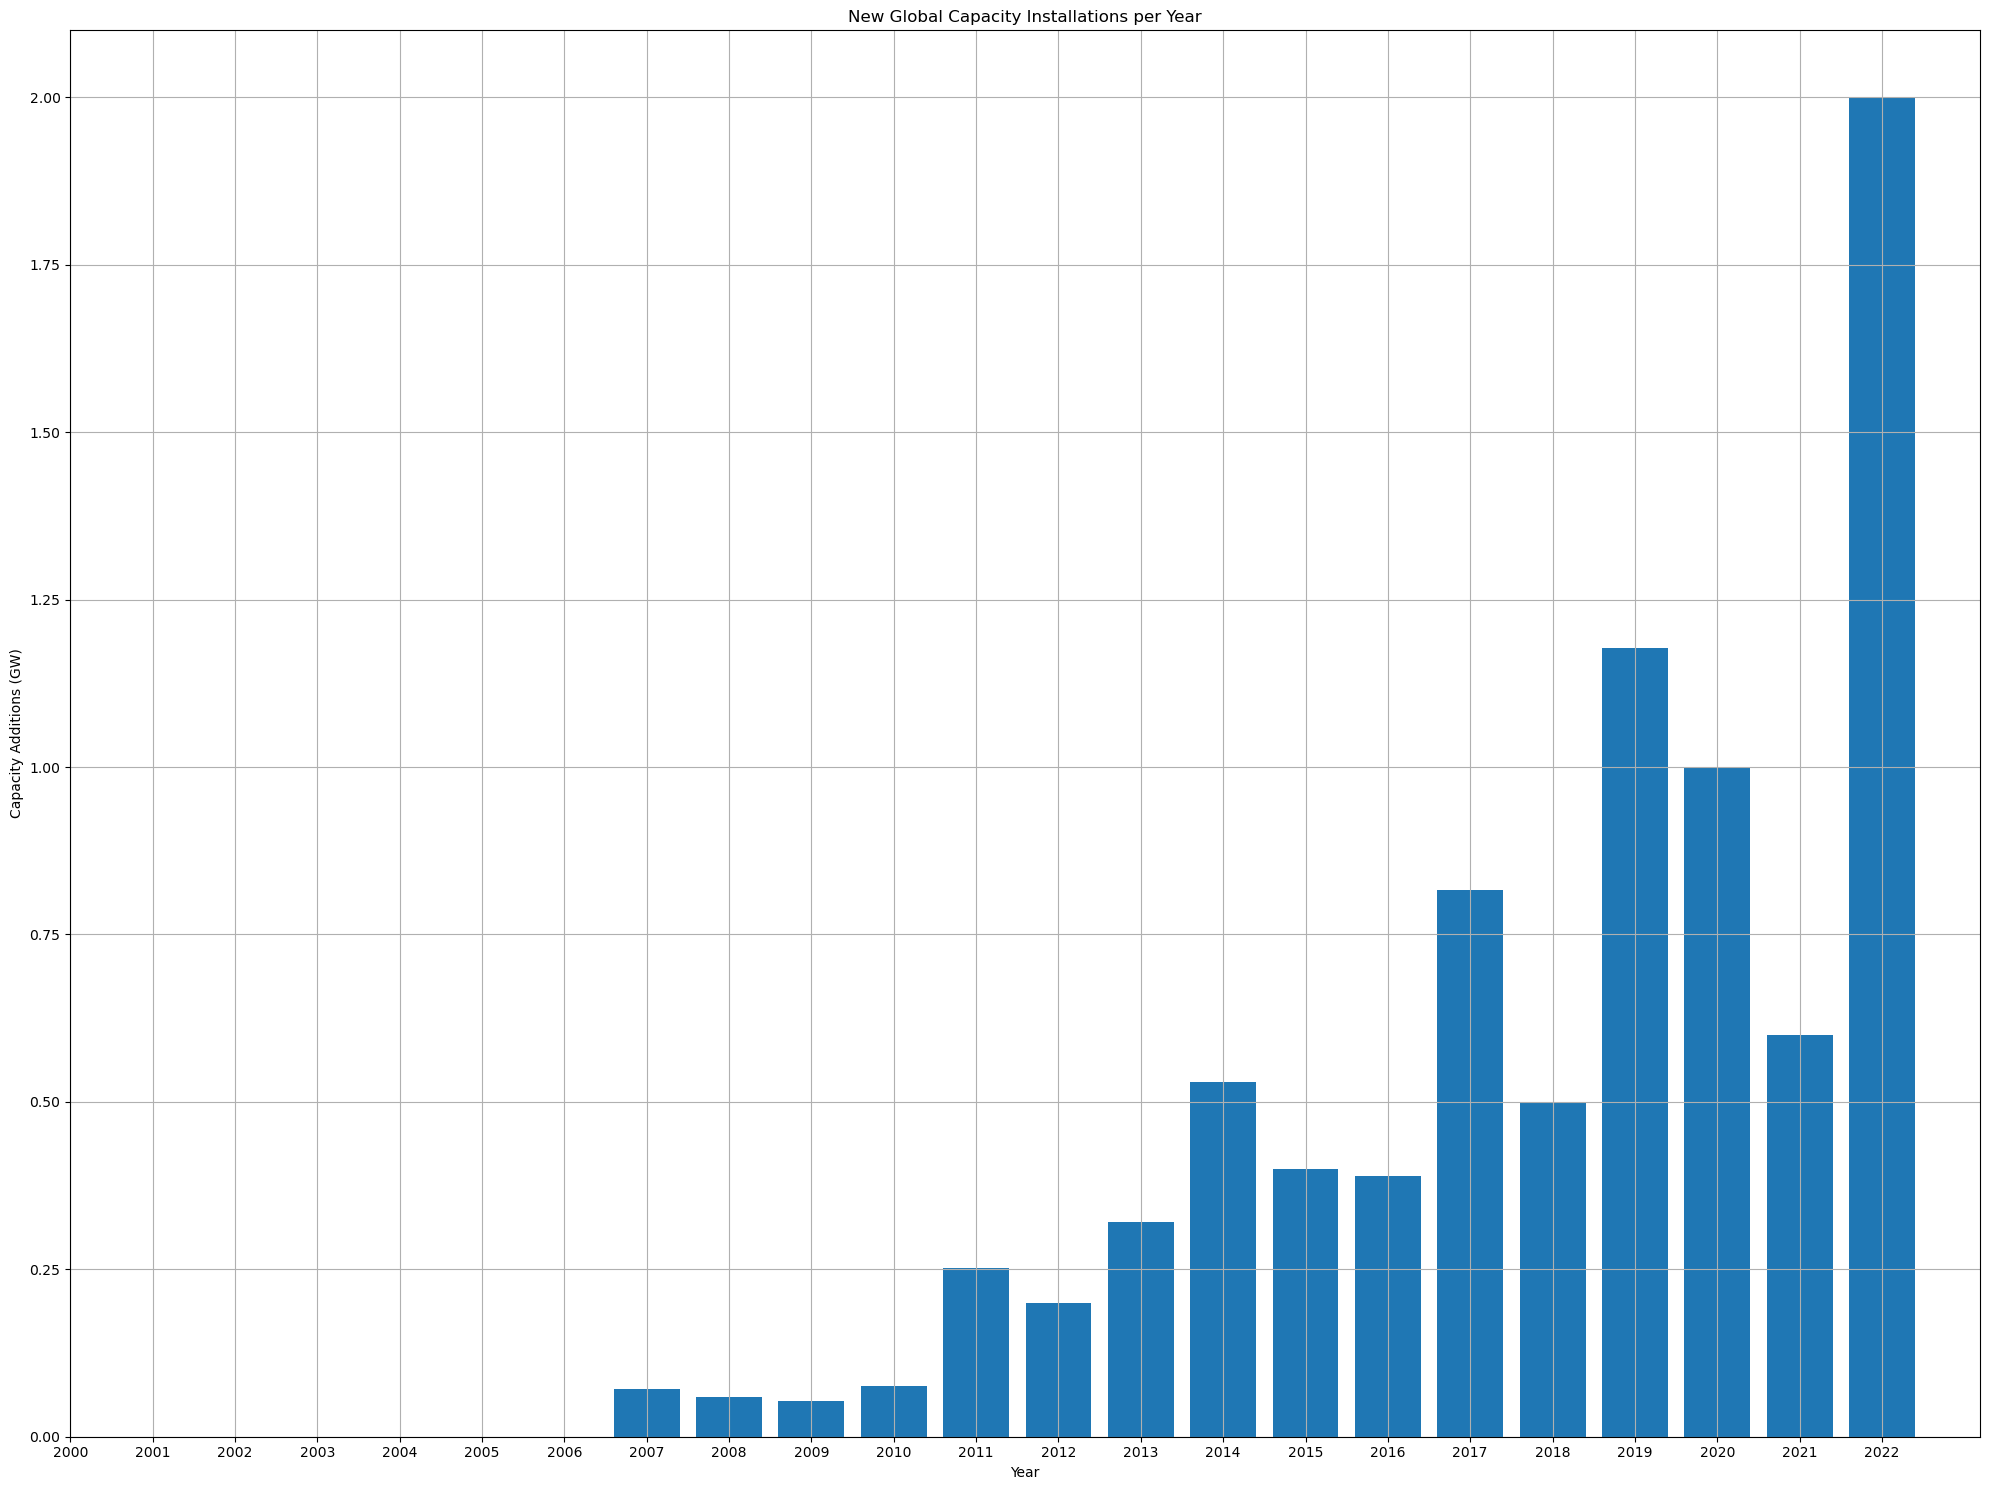

In [37]:
plt.figure(figsize=(20, 15))
plt.bar(gdf_new['Start year'], gdf_new['Capacity (MW)'] / 1000)
plt.title('New Global Capacity Installations per Year')
plt.xlabel('Year')
plt.ylabel('Capacity Additions (GW)')
plt.grid(True)
plt.xticks(range(2000, 2023, 1))  # Show x-axis ticks for every 2 years
plt.tight_layout()
plt.show()

#### Oldest Solar photovoltaic parks

In [38]:
oldest_solar_pv_park = gdf_pv[gdf_pv['Technology Type'].str.contains("PV")].sort_values('Start year').iloc[:1][['Project Name','Country', 'Start year','Status', 'Capacity (MW)']].set_index('Start year')
oldest_solar_pv_park

,Project Name,Country,Status,Capacity (MW)
Start year,,,,
2007.0,Serrezuela solar farm,Spain,operating,32.5


#### Largest operating solar parks 

In [39]:
largest_solar_park = gdf_pv[gdf_pv['Status'] == 'operating'].sort_values('Capacity (MW)', ascending = False).iloc[:3][['Project Name','Country', 'Start year', 'State/Province', 'Technology Type', 'Capacity (MW)']].set_index('Project Name',drop = True)
largest_solar_park

,Country,Start year,State/Province,Technology Type,Capacity (MW)
Project Name,,,,,
Ningxia Lingwu - Hunan Power Export State Energy Investment solar power plant,China,2023.0,Ningxia,PV,2000.0
Noor Abu Dhabi solar farm,United Arab Emirates,2019.0,Abu Dhabi Emirate,PV,1177.0
Qinghai Hainan Talatan 1 solar farm,China,2020.0,Qinghai,PV,1000.0


#### Total capacity (in GW) per project status

In [40]:
(gdf_pv.groupby('Status')['Capacity (MW)'].sum() / 1e3).reset_index().rename(columns={'Capacity (MW)': 'Capacity (GW)'}).set_index('Status')

,Capacity (GW)
Status,
announced,89.0098
construction,88.0061
operating,413.8929
pre-construction,213.4240
retired,0.3740


#### Global Map

C:\ProgramData\anaconda3\envs\esm-2024\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


The largest marker size shows 2000.0MW


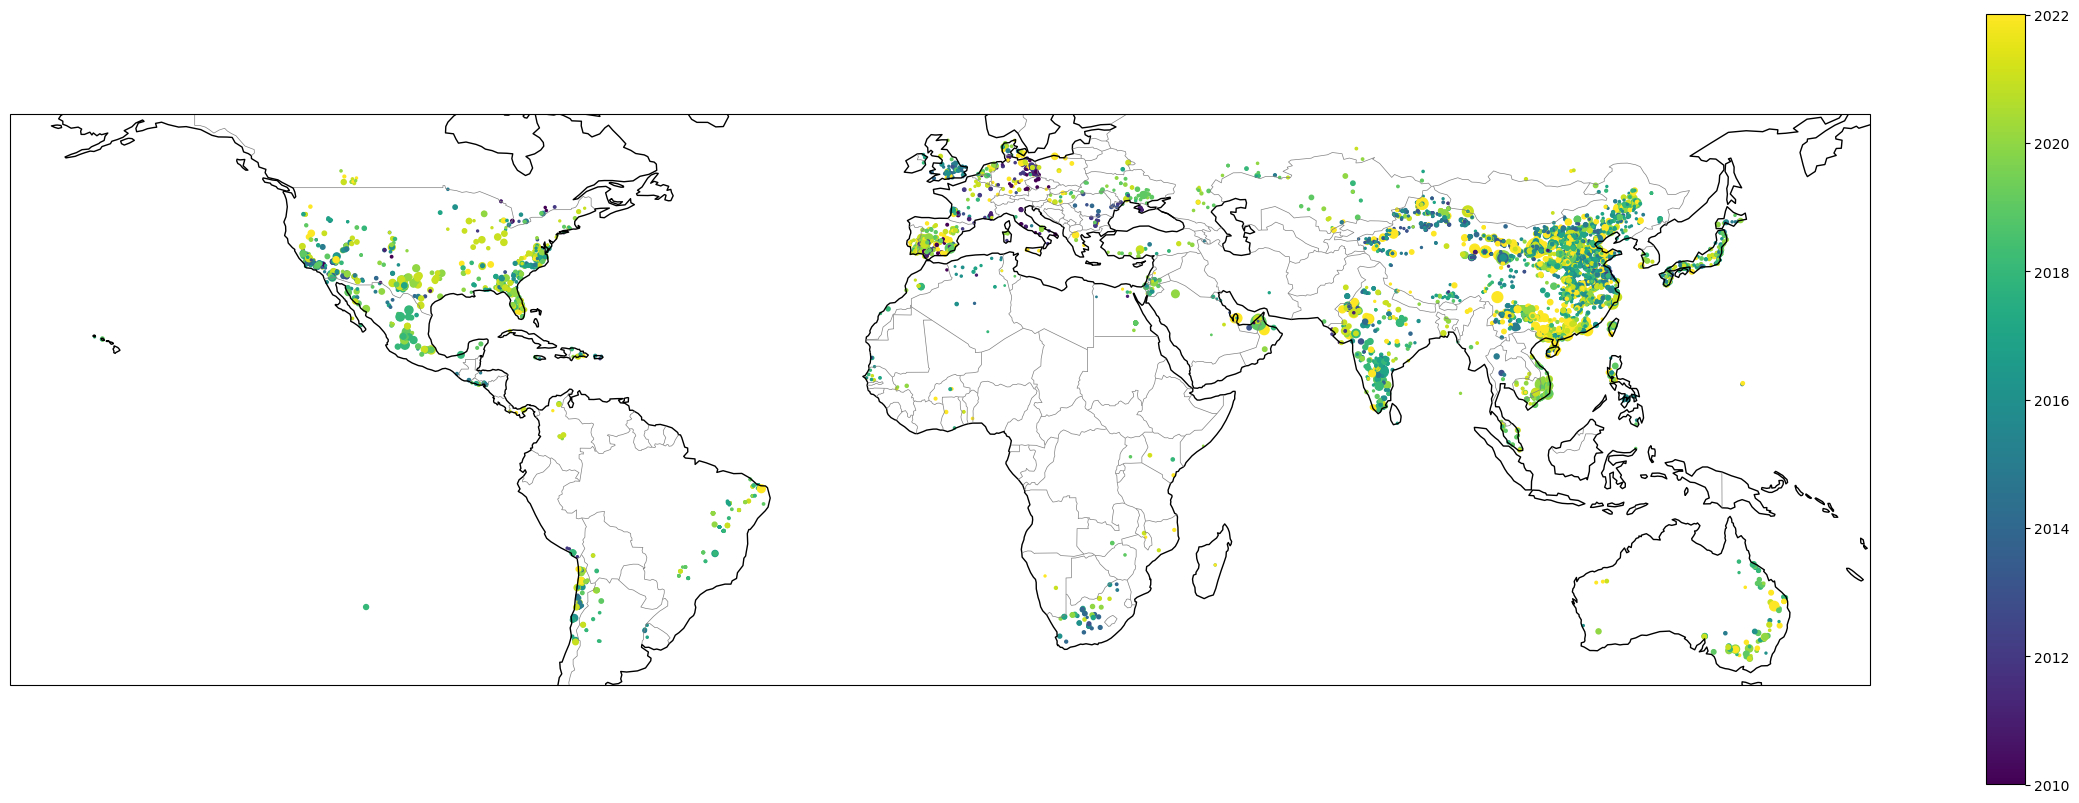

In [41]:
# Solar parks in operation
gdf_op = gdf_pv[gdf_pv['Status'] == 'operating']
fig = plt.figure(figsize=(30, 10))

ax = plt.axes(projection=ccrs.PlateCarree())

gdf_op.plot(
    ax=ax,
    column="Start year",
    markersize= gdf_op["Capacity (MW)"]/10,
    cmap = 'viridis',
    legend = True,
    vmin=2010,
    vmax=2022
)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color="grey", linewidth=0.5)
print(f"The largest marker size shows {gdf_op['Capacity (MW)'].max()}MW")

C:\ProgramData\anaconda3\envs\esm-2024\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


The largest marker size shows 12500.0MW


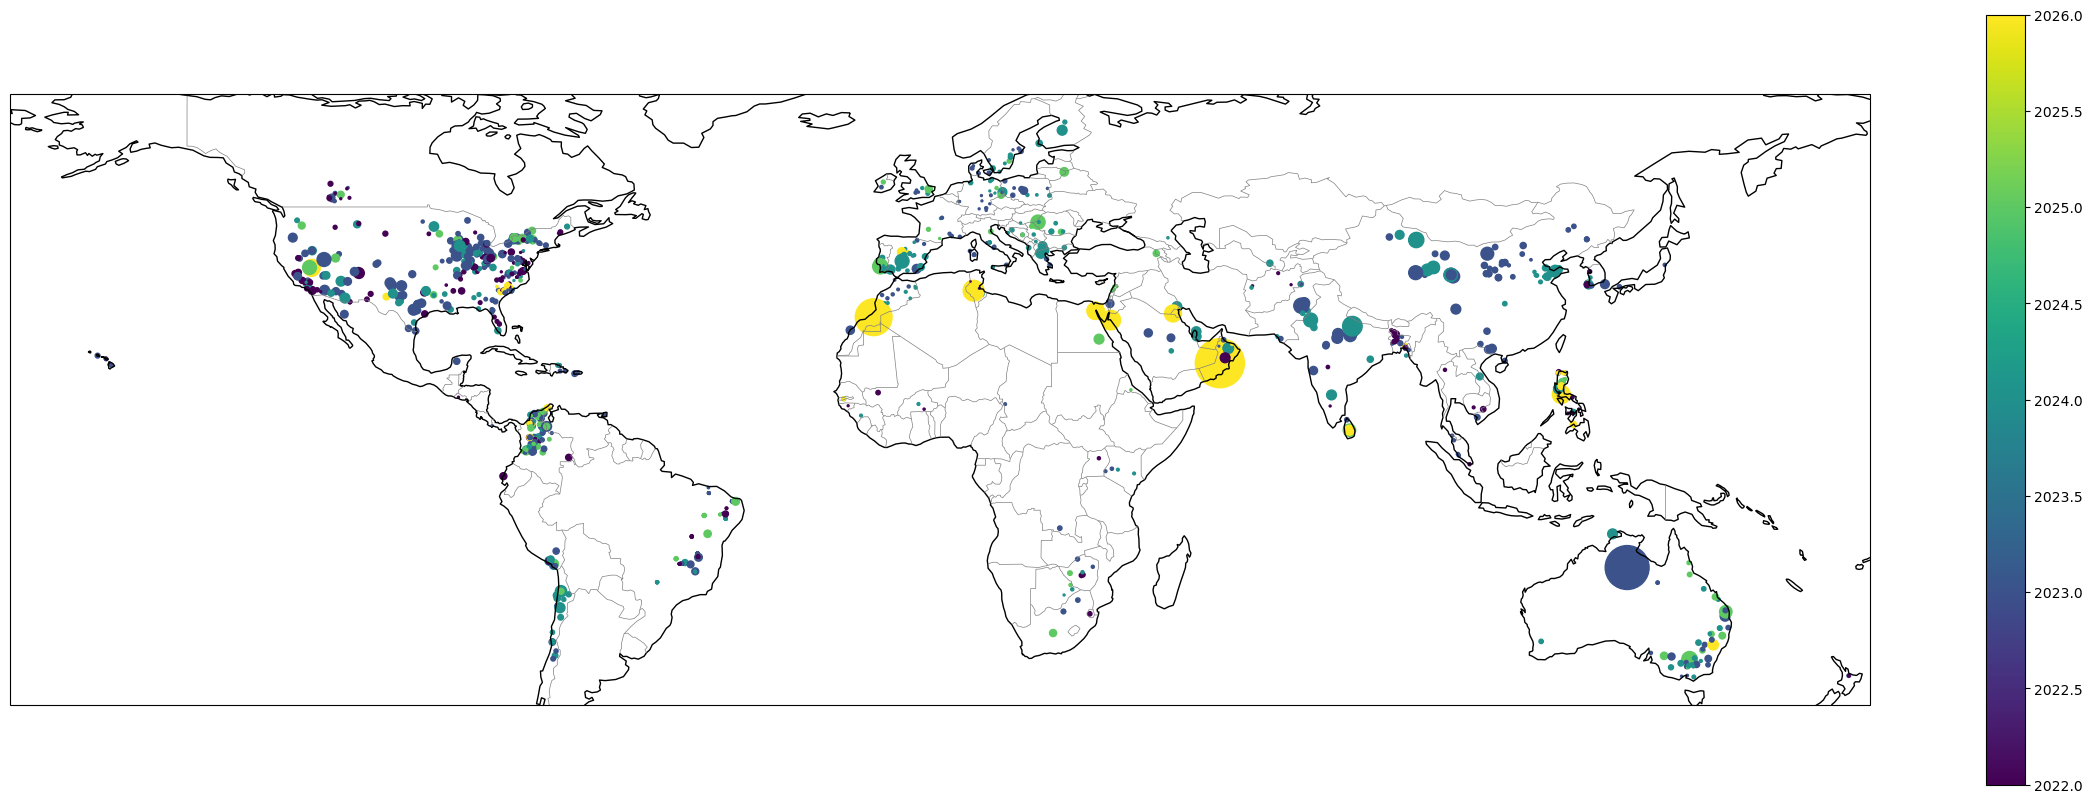

In [42]:
# (ii) Solar parks under pre-construction
gdf_pre_con = gdf_pv[gdf_pv['Status'] == 'pre-construction']
fig = plt.figure(figsize=(30, 10))

ax = plt.axes(projection=ccrs.PlateCarree())

gdf_pre_con.plot(
    ax=ax,
    column="Start year",
    markersize=gdf_pre_con['Capacity (MW)']/10,
    cmap = 'viridis',
    legend = True, 
    vmin=2022,
    vmax=2026
)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color="grey", linewidth=0.5)
print(f"The largest marker size shows {gdf_pre_con['Capacity (MW)'].max()}MW")

#### Capacity - Weighted Mean age of operating solar parks

##### NOTE: All solar parks with a missing start year have been removed in (c)

In [43]:
# Check NA values in start year column
na_values = len(gdf_pv[gdf_pv['Start year'].isna()])
if na_values:
    gdf_pv = gdf_pv[~gdf_pv['Start year'].isna()]
else:
    print("There are no NA values in the start year column")


There are no NA values in the start year column


In [44]:
from datetime import datetime 
# Calculate the age of each solar park
current_year = datetime.now().year

# Considering only solar parks in operation - gdf_op
gdf_op['Age'] = current_year - gdf_op['Start year']

# Calculate the weighted age
gdf_op['Weighted Age'] = gdf_op['Age'] * gdf_op['Capacity (MW)']

# Calculate the capacity-weighted mean age
capacity_weighted_mean_age = gdf_op['Weighted Age'].sum() / gdf_op['Capacity (MW)'].sum()

print(f" The capacity-weighted mean age of all remsining solar parks in operation is {capacity_weighted_mean_age:.2f} years.")

 The capacity-weighted mean age of all remsining solar parks in operation is 5.47 years.


C:\ProgramData\anaconda3\envs\esm-2024\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\ProgramData\anaconda3\envs\esm-2024\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [45]:
from datetime import datetime 

# Calculate the age of each solar park
current_year = datetime.now().year
gdf_op['Age'] = current_year - gdf_op['Start year']

# Calculate the weighted age
gdf_op['Weighted Age'] = gdf_op['Age'] * gdf_op['Capacity (MW)']

# Calculate the capacity-weighted mean age
total_capacity = gdf_op['Capacity (MW)'].sum()
capacity_weighted_mean_age = gdf_op['Weighted Age'].sum() / total_capacity

print(f"Capacity-Weighted Mean Age: {capacity_weighted_mean_age:.2f} years")

Capacity-Weighted Mean Age: 5.47 years


#### Average age of solar parks in operation for each continent

In [46]:
# Groupby object for Weighted Age by region
age_object = gdf_op.groupby('Region')['Weighted Age']

# Groupby object for Capacity by region
rated_capacity_object = gdf_op.groupby('Region')['Capacity (MW)']

In [47]:
# Loop over the GroupBy objects 
weighted_age_table = []
for (continent, age), (continent, rated_capacity) in zip(age_object, rated_capacity_object):
    weighted_age_table.append({'Continent': continent, 'Capacity weighted Age': (age.sum()/rated_capacity.sum()).round(2)})

# Convert to DataFrame and set index to continent
weighted_age_df = pd.DataFrame(weighted_age_table).set_index('Continent')
weighted_age_df

,Capacity weighted Age
Continent,
Africa,6.12
Americas,5.66
Asia,5.37
Europe,6.00
Oceania,4.27


In [48]:
# The oldest solar parks

print(f" The oldest fleet of solar parks is in {weighted_age_df['Capacity weighted Age'].idxmin()}.")

# The newewst solar parks
print(f" The newest fleet of solar parks is in {weighted_age_df['Capacity weighted Age'].idxmax()}.")

 The oldest fleet of solar parks is in Oceania.
 The newest fleet of solar parks is in Africa.


## (IV) European Industrial Sites

Using a dataset of georeferenced industrial sites of energy-intensive industry sectors in Europe, analyze the CO2 emissions.<br>
Source: https://gitlab.com/hotmaps/industrial_sites/industrial_sites_Industrial_Database

#### Read CSV file into dataframe

In [49]:
url_es = "https://tubcloud.tu-berlin.de/s/JamLFf2Pjc6KHfp/download/Industrial_Database.csv"
es = pd.read_csv(url_es, sep = ";", index_col = 0, na_values=None)
es.head()

,SiteID,CompanyName,SiteName,Address,CityCode,City,Country,geom,Subsector,DataSource,Emissions_ETS_2014,Emissions_EPRTR_2014,Production,Fuel_Demand,Excess_Heat_100-200C,Excess_Heat_200-500C,Excess_Heat_500C,Excess_Heat_Total
0,1,voestalpine AG,voestalpine Stahl Donawitz GesmbH,Kerpelystrasse 199,8700,Leoben,Austria,POINT(15.067806 47.03378),Iron and steel,ETS/EPRTR,2808536.0,2810000.0,2726675.56,6346.15,192.34,173.66,0.00,366.01
1,2,voestalpine AG,voestalpine Stahl GmbH,voestalpine-Strasse 3,4020,Linz,Austria,POINT(14.343056 48.281944),Iron and steel,ETS/EPRTR,8698426.0,8660000.0,8444892.86,19732.48,595.71,330.48,40.16,966.36
2,3,Schmid Industrieholding,Wopfinger Baustoffindustrie,Wopfing 156,2754,Waldegg,Austria,POINT(16.085917 47.87225),Cement,ETS/EPRTR,364798.0,408000.0,477398.78,464.13,0.00,69.62,0.00,69.62
3,4,OMV Refining and Marketing GmbH,OMV Refining and Marketing GmbH,Mannswörther Strasse 28,2320,Schwechat,Austria,POINT(16.493889 48.144722),Refineries,ETS/EPRTR,2713186.0,2710000.0,NaN,NaN,0.00,0.00,0.00,0.00
4,5,Zementwerk Hatschek GmbH,Zementwerk Hatschek GmbH,Hatschekstrasse 25,4810,Gmunden,Austria,POINT(13.778 47.92278),Cement,ETS/EPRTR,331127.0,348000.0,607683.04,590.80,0.00,88.62,0.00,88.62


#### Geodataframe

In [50]:
# Drop NaN values
df_es = es.copy()
df_es.dropna(subset=['geom'], inplace=True)

In [51]:
# Convert to a geodataframe
geometry = gpd.GeoSeries.from_wkt(df_es['geom'])
gdf_es = gpd.GeoDataFrame(df_es, geometry=geometry, crs=4326)

# Set SiteID as index of GeoDataFrame
gdf_es.set_index("SiteID")
gdf_es.head()

,SiteID,CompanyName,SiteName,Address,CityCode,City,Country,geom,Subsector,DataSource,Emissions_ETS_2014,Emissions_EPRTR_2014,Production,Fuel_Demand,Excess_Heat_100-200C,Excess_Heat_200-500C,Excess_Heat_500C,Excess_Heat_Total,geometry
0,1,voestalpine AG,voestalpine Stahl Donawitz GesmbH,Kerpelystrasse 199,8700,Leoben,Austria,POINT(15.067806 47.03378),Iron and steel,ETS/EPRTR,2808536.0,2810000.0,2726675.56,6346.15,192.34,173.66,0.00,366.01,POINT (15.06781 47.03378)
1,2,voestalpine AG,voestalpine Stahl GmbH,voestalpine-Strasse 3,4020,Linz,Austria,POINT(14.343056 48.281944),Iron and steel,ETS/EPRTR,8698426.0,8660000.0,8444892.86,19732.48,595.71,330.48,40.16,966.36,POINT (14.34306 48.28194)
2,3,Schmid Industrieholding,Wopfinger Baustoffindustrie,Wopfing 156,2754,Waldegg,Austria,POINT(16.085917 47.87225),Cement,ETS/EPRTR,364798.0,408000.0,477398.78,464.13,0.00,69.62,0.00,69.62,POINT (16.08592 47.87225)
3,4,OMV Refining and Marketing GmbH,OMV Refining and Marketing GmbH,Mannswörther Strasse 28,2320,Schwechat,Austria,POINT(16.493889 48.144722),Refineries,ETS/EPRTR,2713186.0,2710000.0,NaN,NaN,0.00,0.00,0.00,0.00,POINT (16.49389 48.14472)
4,5,Zementwerk Hatschek GmbH,Zementwerk Hatschek GmbH,Hatschekstrasse 25,4810,Gmunden,Austria,POINT(13.778 47.92278),Cement,ETS/EPRTR,331127.0,348000.0,607683.04,590.80,0.00,88.62,0.00,88.62,POINT (13.77800 47.92278)


#### Missing Location

In [52]:
print(f"There are {len(es[es['geom'].isna()])} industrial sites with missing location data")

There are 515 industrial sites with missing location data


#### Fill Emission with EPRTR sourced data 

In [53]:
gdf_test  = gdf_es.copy()

In [54]:
initial_missing_data = len(gdf_es[gdf_es['Emissions_ETS_2014'].isna()])

In [55]:
# Fill missing data from EPRTR column
gdf_es['Emissions_ETS_2014'] = gdf_es['Emissions_ETS_2014'].fillna(gdf_es['Emissions_EPRTR_2014'])

# Check missing data in ETS column
filled_missing_data= len(gdf_es[gdf_es['Emissions_ETS_2014'].isna()])
print(f"The missing data has reduced from {initial_missing_data} to {filled_missing_data} and more emission values shown on the map.")

The missing data has reduced from 1236 to 960 and more emission values shown on the map.


#### Data Visualization

C:\ProgramData\anaconda3\envs\esm-2024\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


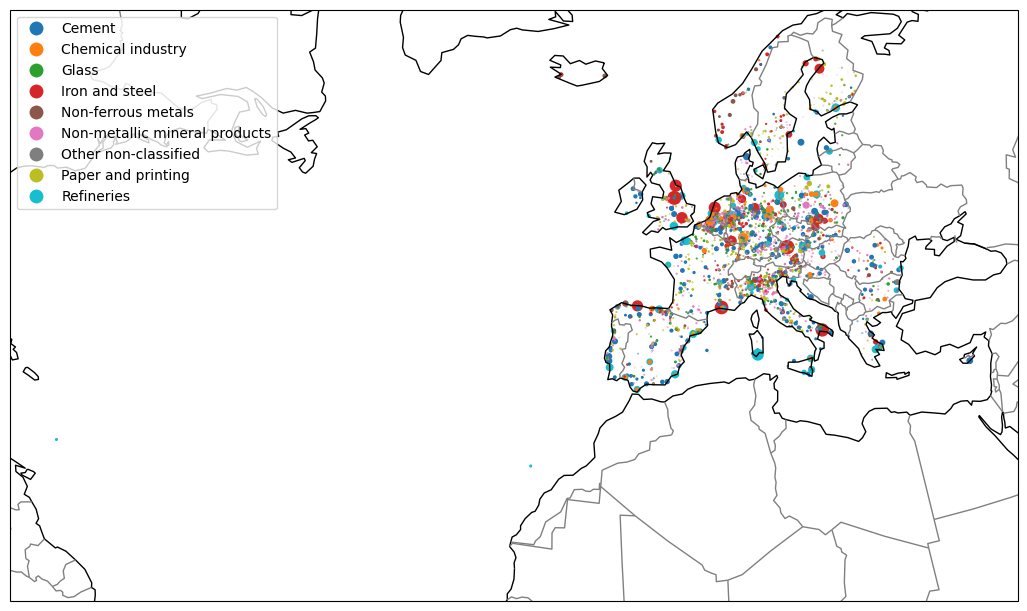

In [56]:
fig = plt.figure(figsize=(13,13))
crs = ccrs.AlbersEqualArea()
ax = plt.axes(projection=crs)


gdf_es.to_crs(crs.proj4_init).plot(
    ax=ax,
    column='Subsector',
    markersize=gdf_test['Emissions_ETS_2014']/1e5,
    legend=True)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color='grey')

#### Emissions per industry

Text(0, 0.5, 'ETS emissions [MtCO2/year]')

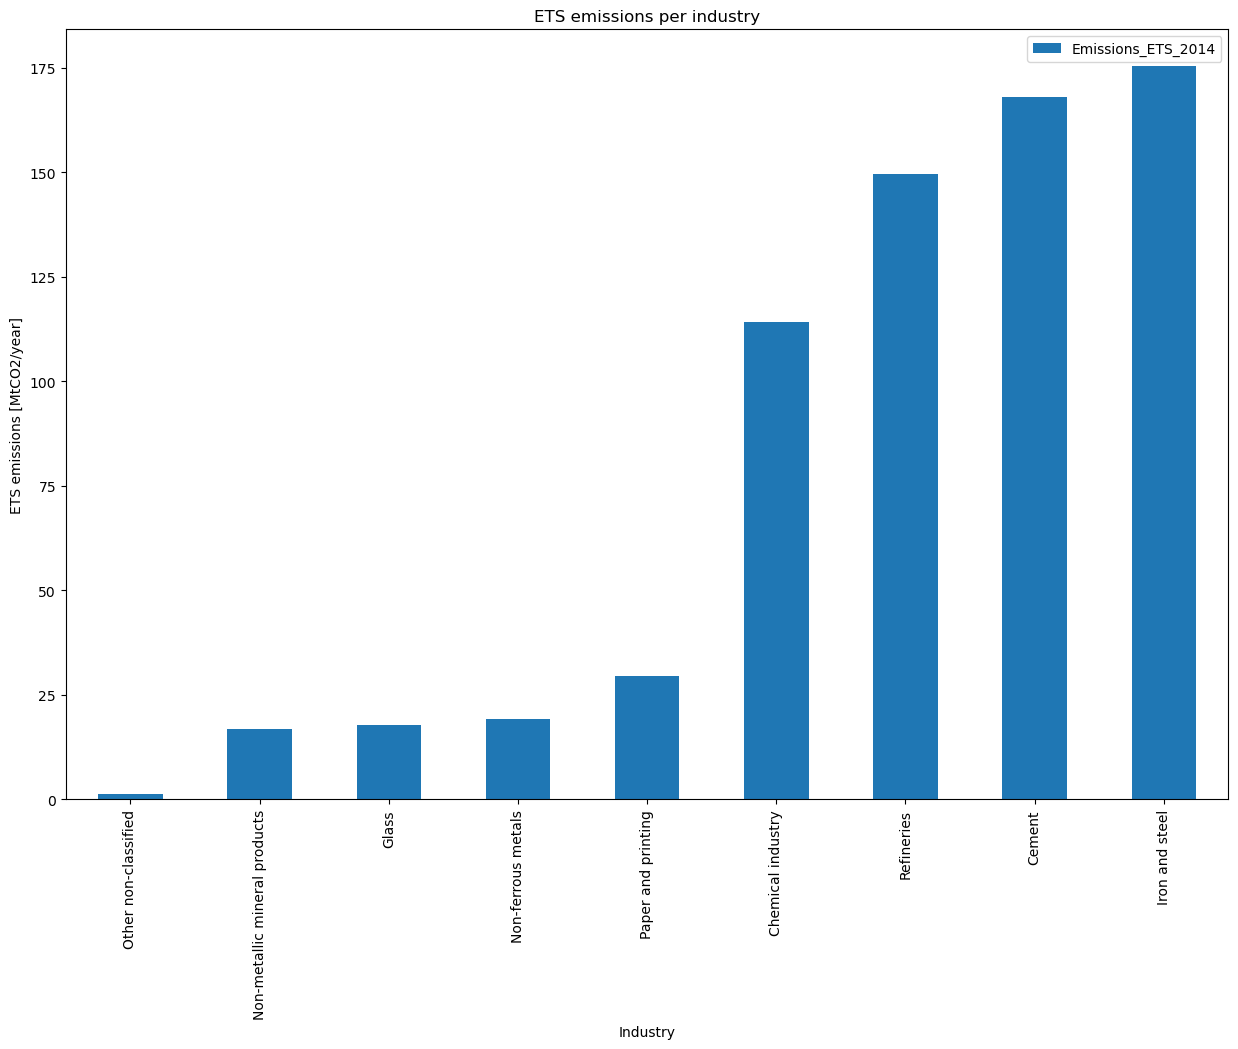

In [57]:
gdf_emissions = pd.DataFrame(gdf_es.groupby("Subsector").Emissions_ETS_2014.sum()).sort_values('Emissions_ETS_2014')/1e6

ax = gdf_emissions.plot(kind='bar', title ="ETS emissions per industry",figsize=(15,10),legend=True)
ax.set_xlabel("Industry")
ax.set_ylabel("ETS emissions [MtCO2/year]")

#### Highest total emissions and share

In [58]:
# Calaculate the highest emissions
highest_emissions = gdf_emissions.sort_values('Emissions_ETS_2014', ascending = False)[:2]

# Check for percentage of total sum
share_emissions = highest_emissions/gdf_emissions.sum()*100
print(f"The {share_emissions['Emissions_ETS_2014'].idxmax()} industry has the largest share of emissions - {share_emissions['Emissions_ETS_2014'].max():.2f}% and the {share_emissions['Emissions_ETS_2014'].idxmin()} industry closely follows  - {share_emissions['Emissions_ETS_2014'].min():.2f}%")

The Iron and steel industry has the largest share of emissions - 25.33% and the Cement industry closely follows  - 24.28%


#### Highest total emissions in the chemical industry

In [59]:
# Subset_dataframe for chemical industries
gdf_chemical = gdf_es[gdf_es['Subsector'] == 'Chemical industry']
gdf_chemical = pd.DataFrame(gdf_es.groupby("Country").Emissions_ETS_2014.sum()).sort_values('Emissions_ETS_2014', ascending  = False)/1e6

# Highest emissions in chemical industry
gdf_chemical_top = gdf_chemical.iloc[:2]

print(f"In the chemical industry, {gdf_chemical_top['Emissions_ETS_2014'].idxmax()} has the highest emissions - {gdf_chemical_top['Emissions_ETS_2014'].max():.2f} MtCO2/year and {gdf_chemical_top['Emissions_ETS_2014'].idxmin()} closely follows  - {gdf_chemical_top['Emissions_ETS_2014'].min():.2f} MtCO2/year")

In the chemical industry, Germany has the highest emissions - 138.33 MtCO2/year and United Kingdom closely follows  - 70.35 MtCO2/year


#### Highest emissions per country per sector

In [60]:
highest_emissions_country = gdf_es.groupby(["Country","Subsector"]).Emissions_ETS_2014.sum()/1e6
highest_emissions_country = highest_emissions_country.unstack()
highest_emissions_country.head()

Subsector,Cement,Chemical industry,Glass,Iron and steel,Non-ferrous metals,Non-metallic mineral products,Other non-classified,Paper and printing,Refineries
Country,,,,,,,,,
Austria,3.974774,2.348263,0.194405,11.893841,0.105598,0.392576,NaN,1.547950,2.713186
Belgium,13.605319,6.303012,1.117211,5.346976,0.195000,0.457165,0.076926,1.917179,6.173719
Bulgaria,1.737308,1.647844,0.459309,0.147015,0.302742,0.189233,0.968878,0.044147,1.031349
Cyprus,1.506658,NaN,NaN,NaN,NaN,0.021578,NaN,NaN,NaN
Czech Republic,3.075739,5.166188,0.659998,3.149940,NaN,0.390747,NaN,1.053407,0.913700


In [61]:
# Loop through each row to determine maximum
emission_table = []

for idx, row in highest_emissions_country.T.items():
    # Find the index of the maximum value for the row
    max_idx = row.idxmax()
    
    # Retrieve the maximum value and column name
    max_value = f"{row[max_idx]:.2f}"
    column_name = max_idx
    
# Append the information to the table
    emission_table.append({'Country': idx, 'Industry': column_name, 'Maximum Emissions (MtCO2/year)': max_value})

# Create DataFrame from the result_table
emission_df = pd.DataFrame(emission_table)

# Set country as index of  DataFrame
emission_df.set_index('Country')

,Industry,Maximum Emissions (MtCO2/year)
Country,,
Austria,Iron and steel,11.89
Belgium,Cement,13.61
Bulgaria,Cement,1.74
Cyprus,Cement,1.51
Czech Republic,Chemical industry,5.17
Denmark,Cement,1.72
Estonia,Cement,0.86
Finland,Iron and steel,4.53
France,Chemical industry,15.36


#### Emissions in Poland

In [62]:
# Subset dataframe for countryies in Poland
gdf_polish = gdf_es[gdf_es['Country'] == 'Poland']

gdf_polish.set_index('SiteID')

,CompanyName,SiteName,Address,CityCode,City,Country,geom,Subsector,DataSource,Emissions_ETS_2014,Emissions_EPRTR_2014,Production,Fuel_Demand,Excess_Heat_100-200C,Excess_Heat_200-500C,Excess_Heat_500C,Excess_Heat_Total,geometry
SiteID,,,,,,,,,,,,,,,,,,
767,NaN,Grupa LOTOS S.A.,Elbląska 135,NaN,Gdańsk,Poland,POINT(18.732 54.345),Refineries,ETS/EPRTR,1520299.0,1820000.0,NaN,NaN,0.00,0.00,0.00,0.00,POINT (18.73200 54.34500)
768,NaN,Polski Koncern Naftowy ORLEN S.A.,Chemików 7,NaN,Płock,Poland,POINT(19.67325 52.586167),Refineries,ETS/EPRTR,2281754.0,NaN,NaN,NaN,0.00,0.00,0.00,0.00,POINT (19.67325 52.58617)
769,NaN,Koksownia Radlin,Hutnicza 1,NaN,RADLIN,Poland,POINT(18.486857 50.037876),Iron and steel,ETS/EPRTR,127809.0,128000.0,702911.45,265.06,0.00,0.00,14.90,14.90,POINT (18.48686 50.03788)
770,Arcelor Mittal Poland,"ArcelorMittal Poland S.A., Oddział w Krakowie",Ujastek 1,NaN,Kraków,Poland,POINT(20.092361 50.080333),Iron and steel,ETS/EPRTR,1195347.0,2690000.0,23621745.20,2864.22,94.76,0.00,0.00,94.76,POINT (20.09236 50.08033)
771,NaN,"Wałbrzyskie Zakłady Koksownicze ""Victoria"" S.A",Kosteckiego 9,NaN,Wałbrzych,Poland,POINT(16.24114 50.755735),Iron and steel,ETS/EPRTR,78187.0,NaN,430005.22,162.15,0.00,0.00,9.12,9.12,POINT (16.24114 50.75574)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,KOMBINAT KOKSOCHEMICZNY ZABRZE S.A.,KOKSOWNIA JADWIGA,ZAMKOWA 9,41803,ZABRZE,Poland,POINT(18.828228 50.327115),Iron and steel,ETS,62193.0,NaN,1393443.64,1910.65,63.21,0.00,0.00,63.21,POINT (18.82823 50.32711)
4556,Ferrostal Łabędy Sp. z o.o.,Ferrostal Łabędy Sp. z o.o.,Zawadzkiego 47,44109,Gliwice,Poland,POINT(18.615042 50.351552),Iron and steel,ETS,30180.0,NaN,676187.49,77.92,0.00,23.37,14.02,37.40,POINT (18.61504 50.35155)
4557,Trend Glass Sp. z o.o.,TREND GLASS Sp. z o.o.,Zubrzyckiego 11,26600,Radom,Poland,POINT(21.206054 51.418002),Glass,ETS,49681.0,NaN,NaN,NaN,0.00,0.00,0.00,0.00,POINT (21.20605 51.41800)


In [63]:
emissions_polish = (gdf_polish.groupby(["CompanyName", "Subsector"]).Emissions_ETS_2014.sum().sort_values(ascending = False)/1e6).round(2)
emissions_polish.head(10).reset_index().rename(columns = {'Emissions_ETS_2014': 'Emissions_ETS_2014 (MtCO2/year)', 'CompanyName':'Company'})

,Company,Subsector,Emissions_ETS_2014 (MtCO2/year)
0,Grupa Ożarów S.A.,Non-metallic mineral products,1.90
1,CRH,Cement,1.84
2,Arcelor Mittal Poland,Iron and steel,1.20
3,LAFARGE CEMENT S.A.,Cement,1.08
4,Zakłady Azotowe w Tarnowie-Mościcach S.A.,Chemical industry,0.95
5,Orlen S.A.,Chemical industry,0.92
6,Polski Koncern Naftowy ORLEN S.A.,Chemical industry,0.85
7,Grupa Azoty S. A. w Tarnowie,Chemical industry,0.80
8,Grupa Ożarów S.A.,Cement,0.66
9,"ZGH ""Bolesław"" S.A.",Non-ferrous metals,0.49


#### Chloropleth map

In [64]:
# Read data into GeoDataFrame
url_nuts =  "https://tubcloud.tu-berlin.de/s/5WJ6pGsBKR7a3sp/download/NUTS_RG_10M_2021_4326.geojson"
nuts = gpd.read_file(url_nuts)
nuts.set_index('id', inplace = True)
nuts.head()

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
id,,,,,,,,,,
BG423,BG423,3,BG,Pazardzhik,Пазарджик,3.0,2,3,BG423,"POLYGON ((24.42101 42.55306, 24.41032 42.46950..."
BG424,BG424,3,BG,Smolyan,Смолян,3.0,3,3,BG424,"POLYGON ((25.07422 41.79348, 25.05851 41.75177..."
BG425,BG425,3,BG,Kardzhali,Кърджали,3.0,3,3,BG425,"POLYGON ((25.94863 41.32034, 25.90644 41.30757..."
CH011,CH011,3,CH,Vaud,Vaud,3.0,2,3,CH011,"MULTIPOLYGON (((6.86623 46.90929, 6.89621 46.9..."
CH012,CH012,3,CH,Valais,Valais,3.0,2,3,CH012,"POLYGON ((8.47767 46.52760, 8.39953 46.48872, ..."


In [65]:
# Filter by NUTS-2 level
nuts2 =  nuts.query("LEVL_CODE == 2")
nuts2.explore()

In [66]:
# Check coordinate reference system of nuts2 region data and geodataframe
nuts2.crs,gdf_es.crs

(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [67]:
# Join the dataframe and the NUTS-2 region data
joined_nuts2 = gdf_es.sjoin(nuts2)
joined_nuts2.head()

,SiteID,CompanyName,SiteName,Address,CityCode,City,Country,geom,Subsector,DataSource,...,index_right,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID
0,1,voestalpine AG,voestalpine Stahl Donawitz GesmbH,Kerpelystrasse 199,8700,Leoben,Austria,POINT(15.067806 47.03378),Iron and steel,ETS/EPRTR,...,AT22,AT22,2,AT,Steiermark,Steiermark,0.0,0,0,AT22
1,2,voestalpine AG,voestalpine Stahl GmbH,voestalpine-Strasse 3,4020,Linz,Austria,POINT(14.343056 48.281944),Iron and steel,ETS/EPRTR,...,AT31,AT31,2,AT,Oberösterreich,Oberösterreich,0.0,0,0,AT31
2,3,Schmid Industrieholding,Wopfinger Baustoffindustrie,Wopfing 156,2754,Waldegg,Austria,POINT(16.085917 47.87225),Cement,ETS/EPRTR,...,AT12,AT12,2,AT,Niederösterreich,Niederösterreich,0.0,0,0,AT12
3,4,OMV Refining and Marketing GmbH,OMV Refining and Marketing GmbH,Mannswörther Strasse 28,2320,Schwechat,Austria,POINT(16.493889 48.144722),Refineries,ETS/EPRTR,...,AT12,AT12,2,AT,Niederösterreich,Niederösterreich,0.0,0,0,AT12
4,5,Zementwerk Hatschek GmbH,Zementwerk Hatschek GmbH,Hatschekstrasse 25,4810,Gmunden,Austria,POINT(13.778 47.92278),Cement,ETS/EPRTR,...,AT31,AT31,2,AT,Oberösterreich,Oberösterreich,0.0,0,0,AT31


In [68]:
# Reprojecting the dataframe to an equal-area projection
nuts2 = nuts2.to_crs(3035)

# Calculate area of region in km2
area = nuts2.area / 1e6
area.head()

id
DE50     423.605494
DE60     746.525693
DE71    7380.655840
DE72    5437.113959
DE73    8255.844829
dtype: float64

In [69]:
# Group by NUTS-ID and sum emissions
emissions_nuts = joined_nuts2.groupby("NUTS_ID")['Emissions_ETS_2014'].sum()

In [70]:
# Check index difference
nuts2.index.difference(emissions_nuts.index)

Index(['AL01', 'AL02', 'AL03', 'AT13', 'CH04', 'CH06', 'CH07', 'EL41', 'EL42',
       'EL62', 'ES63', 'ES64', 'FRH0', 'FRM0', 'FRY1', 'FRY4', 'FRY5', 'HR05',
       'LI00', 'ME00', 'MK00', 'MT00', 'NL23', 'NL31', 'NO02', 'NO0B', 'PT20',
       'PT30', 'RS11', 'RS12', 'RS21', 'RS22', 'TR10', 'TR21', 'TR22', 'TR31',
       'TR32', 'TR33', 'TR41', 'TR42', 'TR51', 'TR52', 'TR61', 'TR62', 'TR63',
       'TR71', 'TR72', 'TR81', 'TR82', 'TR83', 'TR90', 'TRA1', 'TRA2', 'TRB1',
       'TRB2', 'TRC1', 'TRC2', 'TRC3', 'UKI3', 'UKI4', 'UKI5', 'UKI6', 'UKK3'],
      dtype='object')

In [71]:
# Reindex the emissions series to include all NUTS 2 regions
emissions_nuts = emissions_nuts.reindex(nuts2.index)

print(f" There are {len(nuts2.index.difference(emissions_nuts.index))} index differences between the dataframes")
emissions_nuts.head()

 There are 0 index differences between the dataframes


id
DE50    3048376.0
DE60    2046753.0
DE71     295393.0
DE72     704757.0
DE73     472594.0
Name: Emissions_ETS_2014, dtype: float64

(2000000.0, 6000000.0)

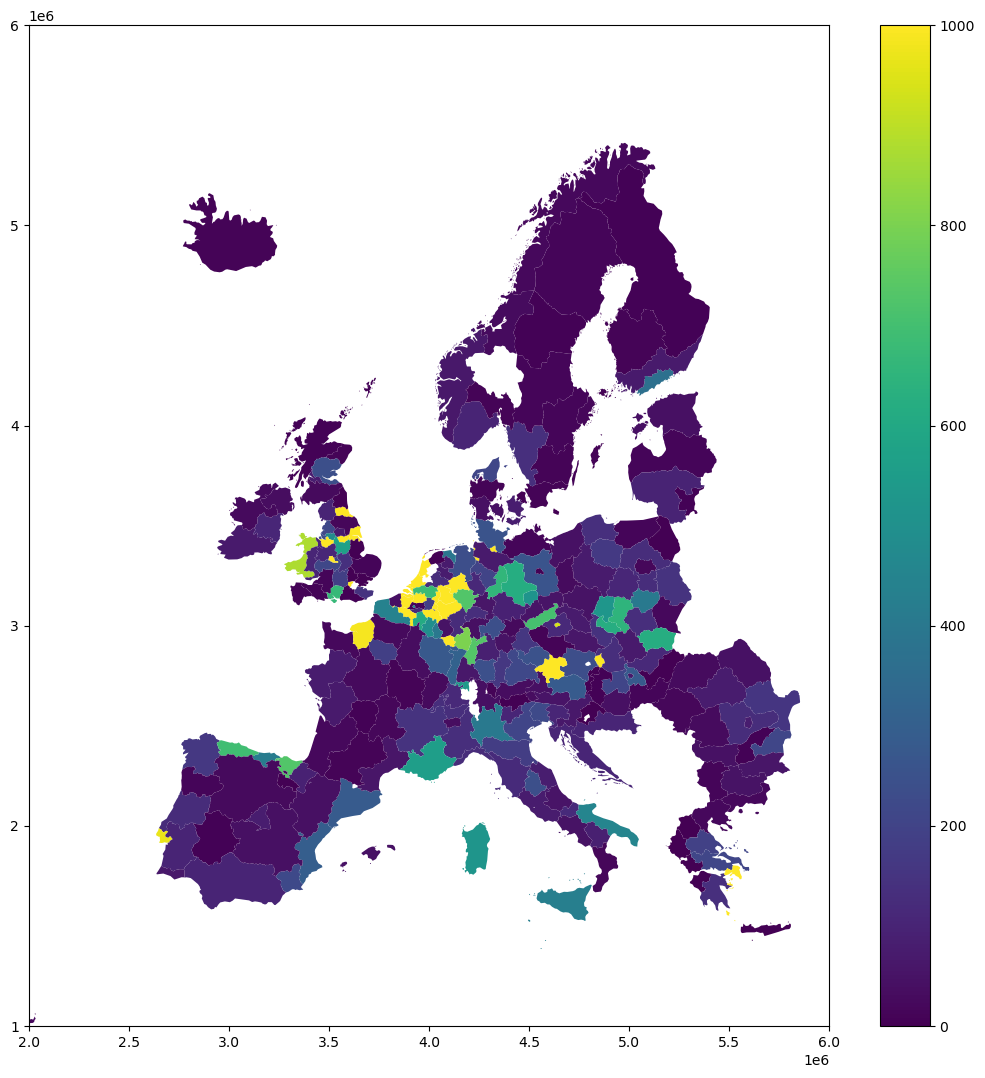

In [72]:
# Plot total emissions per NUTS 2 region normalized by are - tCO2/year/km2

nuts2.plot(figsize=(13, 13), column=emissions_nuts / area, legend=True, vmax = 1e3)
plt.ylim(1e6, 6e6)
plt.xlim(2e6, 6e6)

#### Highest level of industry emissions in Austria : NUTS-3

In [73]:
# Filter by NUTS-3 level
nuts3 =  nuts.query("LEVL_CODE == 3")
nuts3.explore()

In [74]:
# Check coordinate reference system of nuts2 region data and geodataframe
nuts3.crs,gdf_es.crs

(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [75]:
# Join the dataframe and the NUTS-3 region data
joined_nuts3 = gdf_es.sjoin(nuts3)
joined_nuts3.head()

,SiteID,CompanyName,SiteName,Address,CityCode,City,Country,geom,Subsector,DataSource,...,index_right,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID
0,1,voestalpine AG,voestalpine Stahl Donawitz GesmbH,Kerpelystrasse 199,8700,Leoben,Austria,POINT(15.067806 47.03378),Iron and steel,ETS/EPRTR,...,AT225,AT225,3,AT,West- und Südsteiermark,West- und Südsteiermark,3.0,3,3,AT225
1,2,voestalpine AG,voestalpine Stahl GmbH,voestalpine-Strasse 3,4020,Linz,Austria,POINT(14.343056 48.281944),Iron and steel,ETS/EPRTR,...,AT312,AT312,3,AT,Linz-Wels,Linz-Wels,4.0,2,3,AT312
2,3,Schmid Industrieholding,Wopfinger Baustoffindustrie,Wopfing 156,2754,Waldegg,Austria,POINT(16.085917 47.87225),Cement,ETS/EPRTR,...,AT122,AT122,3,AT,Niederösterreich-Süd,Niederösterreich-Süd,3.0,2,3,AT122
3,4,OMV Refining and Marketing GmbH,OMV Refining and Marketing GmbH,Mannswörther Strasse 28,2320,Schwechat,Austria,POINT(16.493889 48.144722),Refineries,ETS/EPRTR,...,AT127,AT127,3,AT,Wiener Umland/Südteil,Wiener Umland/Südteil,4.0,2,3,AT127
4,5,Zementwerk Hatschek GmbH,Zementwerk Hatschek GmbH,Hatschekstrasse 25,4810,Gmunden,Austria,POINT(13.778 47.92278),Cement,ETS/EPRTR,...,AT315,AT315,3,AT,Traunviertel,Traunviertel,3.0,3,3,AT315


In [76]:
# Check for NUTS-3 region with highest emissions

emissions_AT = joined_nuts3[joined_nuts3['NUTS_ID'].str.contains('AT')].groupby('NUTS_ID')['Emissions_ETS_2014'].sum()
max_emissions_AT = emissions_AT.idxmax()

print(f" The NUTS-3 region - {max_emissions_AT} has the highest emissions of {emissions_AT.max()/1e6:.2f} MtCO2/year.")

 The NUTS-3 region - AT312 has the highest emissions of 9.23 MtCO2/year.


In [77]:
# Common name of region

common_name = joined_nuts3[joined_nuts3['NUTS_ID'] == max_emissions_AT]['NUTS_NAME'].unique()
print(f"The common name of the region is {common_name[0]}.")

The common name of the region is Linz-Wels.


In [78]:
# Companies in region

joined_nuts3[joined_nuts3['NUTS_ID'] == max_emissions_AT][['CompanyName', 'Subsector']].rename(columns = {'CompanyName': 'Company'}).set_index('Company')

,Subsector
Company,
voestalpine AG,Iron and steel
Nettingsdorfer Service Center,Paper and printing
DSM Life Science Products Intern,Chemical industry
Ziegelwerk Neuhofen K.F. u. DI H. Obermair GmbH & Co KG,Non-metallic mineral products
Ziegelwerk Pichler Wels Gesellschaft m.b.H.,Non-metallic mineral products
Dr. Franz Feurstein Gesellschaft m.b.H.,Paper and printing
Leitl Spannton Gesellschaft m.b.H.,Non-metallic mineral products
voestalpine Stahl GmbH,Cement
Martin Pichler Ziegelwerk GmbH.,Non-metallic mineral products
